In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import gsw
import numpy as np
from mpl_toolkits.basemap import Basemap
import plotly.graph_objs as go

In [5]:
# Get data into dataframe
df = pd.read_csv('../../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to only have temperature, salinity and dissolved oxygen
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','Datetime_[UTC]']]
df_ST['year'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.year
df_ST['month'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.month
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','year', 'month']]

In [64]:
# Peisong code altered to work on profiles
def profileNo_vs_latlon_bins(
    df: pd.DataFrame,
    lat_step: float,
    lon_step: float,
    show_threshold: bool = False,
    threshold_quantile: float = 0.95
) -> None:
    """
    Plot the number of profiles in each latitude-longitude bin.

    Args:
        ds (pd.DataFrame): The dataset to plot.
        lat_step (float): The latitude step size for binning.
        lon_step (float): The longitude step size for binning.
        show_threshold (bool, optional): Whether to show the threshold marker. Defaults to False.
        threshold_quantile (float, optional): The quantile value for threshold calculation. Defaults to 0.95.

    Returns:
        None
    """

    lon_bins = pd.cut(df['Longitude_[deg_E]'], bins=np.arange(-180, 185, lon_step))
    lat_bins = pd.cut(df['Latitude_[deg_N]'], bins=np.arange(-90, 95, lat_step))

    latlon_groups = df.groupby([lon_bins, lat_bins])

    g_len = []
    for group_key in latlon_groups.groups:
        try:
            group = latlon_groups.get_group(group_key)
            # print(f"Group {group_key}: {len(group)} rows")
            g_len.append(len(group))
        except KeyError:
            # Handle the KeyError gracefully
            print(f"No data points for group {group_key}")

    g_len_sorted = sorted(g_len)
    transition_point = None

    g_len_diff = np.diff(g_len_sorted)

    threshold = np.quantile(g_len_diff, threshold_quantile)  # set a threshold for the difference between adjacent elements

    for i in range(1, len(g_len_sorted)):
        if g_len_sorted[i] - g_len_sorted[i-1] > threshold:
            transition_point = i - 1
            break

    trace = go.Scatter(
        x=list(range(len(g_len_sorted))),
        y=g_len_sorted
    )

    if show_threshold:
        if transition_point is not None:
            red_dot = go.Scatter(
                x=[transition_point],
                y=[g_len_sorted[transition_point]],
                mode='markers',
                marker=dict(color='red', size=10)
            )
            fig_data = [trace, red_dot]
        else:
            fig_data = [trace]
    else:
        fig_data = [trace]

    layout = go.Layout(
        xaxis=dict(title='Bin No.'),
        yaxis=dict(title='Number of points per bin')
    )

    fig = go.Figure(data=fig_data, layout=layout)
    fig.show()

In [7]:
profileNo_vs_latlon_bins(df_ST, lat_step=5, lon_step=5, show_threshold=True, threshold_quantile=0.99)

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_38717/1342144697.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  latlon_groups = df.groupby([lon_bins, lat_bins])


In [50]:
def plot_heatmap_npts(ds_cleaned, n_lon_bins=72, n_lat_bins=9):
    lon_min, lon_max = -180, 180
    lat_min, lat_max = 55, 90
    resolution = 'l'

    # Equal-area bins: uniform in longitude, uniform in sin(latitude)
    lon_bins = np.linspace(lon_min, lon_max, n_lon_bins + 1)
    sin_min = np.sin(np.radians(lat_min))
    sin_max = np.sin(np.radians(lat_max))
    sin_bins = np.linspace(sin_min, sin_max, n_lat_bins + 1)
    lat_bins = np.degrees(np.arcsin(sin_bins))

    # Find number of points per bin
    count = np.zeros((n_lon_bins, n_lat_bins), dtype=int)
    for i in range(len(lon_bins)-1):
        for j in range(len(lat_bins)-1):
            count[i,j] = ds_cleaned[ds_cleaned['Longitude_[deg_E]'].between(lon_bins[i], lon_bins[i+1]) & ds_cleaned['Latitude_[deg_N]'].between(lat_bins[j], lat_bins[j+1])].shape[0]

    fig = plt.figure(figsize=(8,8), dpi=300)
    m = Basemap(projection='npstere', boundinglat=lat_min, lon_0=0, resolution=resolution)

    m.drawcoastlines()
    m.fillcontinents(color='grey', lake_color='lightblue')

    # Draw sine-lat bin edges as lightgrey lines
    # Latitude lines (at each lat_bins edge)
    for lat in lat_bins:
        lons = np.linspace(lon_min, lon_max, 500)
        lats = np.full_like(lons, lat)
        x, y = m(lons, lats)
        m.plot(x, y, color='grey', linewidth=0.05, zorder=3)

    # Longitude lines (at each lon_bins edge)
    for lon in lon_bins:
        lats = np.linspace(lat_min, lat_max, 500)
        lons = np.full_like(lats, lon)
        x, y = m(lons, lats)
        m.plot(x, y, color='grey', linewidth=0.05, zorder=3)

    # Plot data on top
    X, Y = np.meshgrid(lon_bins, lat_bins)
    X_map, Y_map = m(X, Y)

    cmap = plt.get_cmap('Wistia').copy()
    cmap.set_under(color='white', alpha=1.0)
    cmap.set_over(color='white', alpha=1.0)

    m.pcolormesh(X_map, Y_map, count.T, cmap=cmap, vmin=1, vmax=None)

    # Redraw coastlines on top of pcolormesh
    m.drawcoastlines()
    m.fillcontinents(color='lightgrey', lake_color='lightblue')

    cbar = m.colorbar(location='bottom', pad="5%")
    cbar.set_label('Number of points in bin')

    plt.xticks([])
    plt.yticks([])
    plt.title('Number of Points per Bin')

    plt.show()

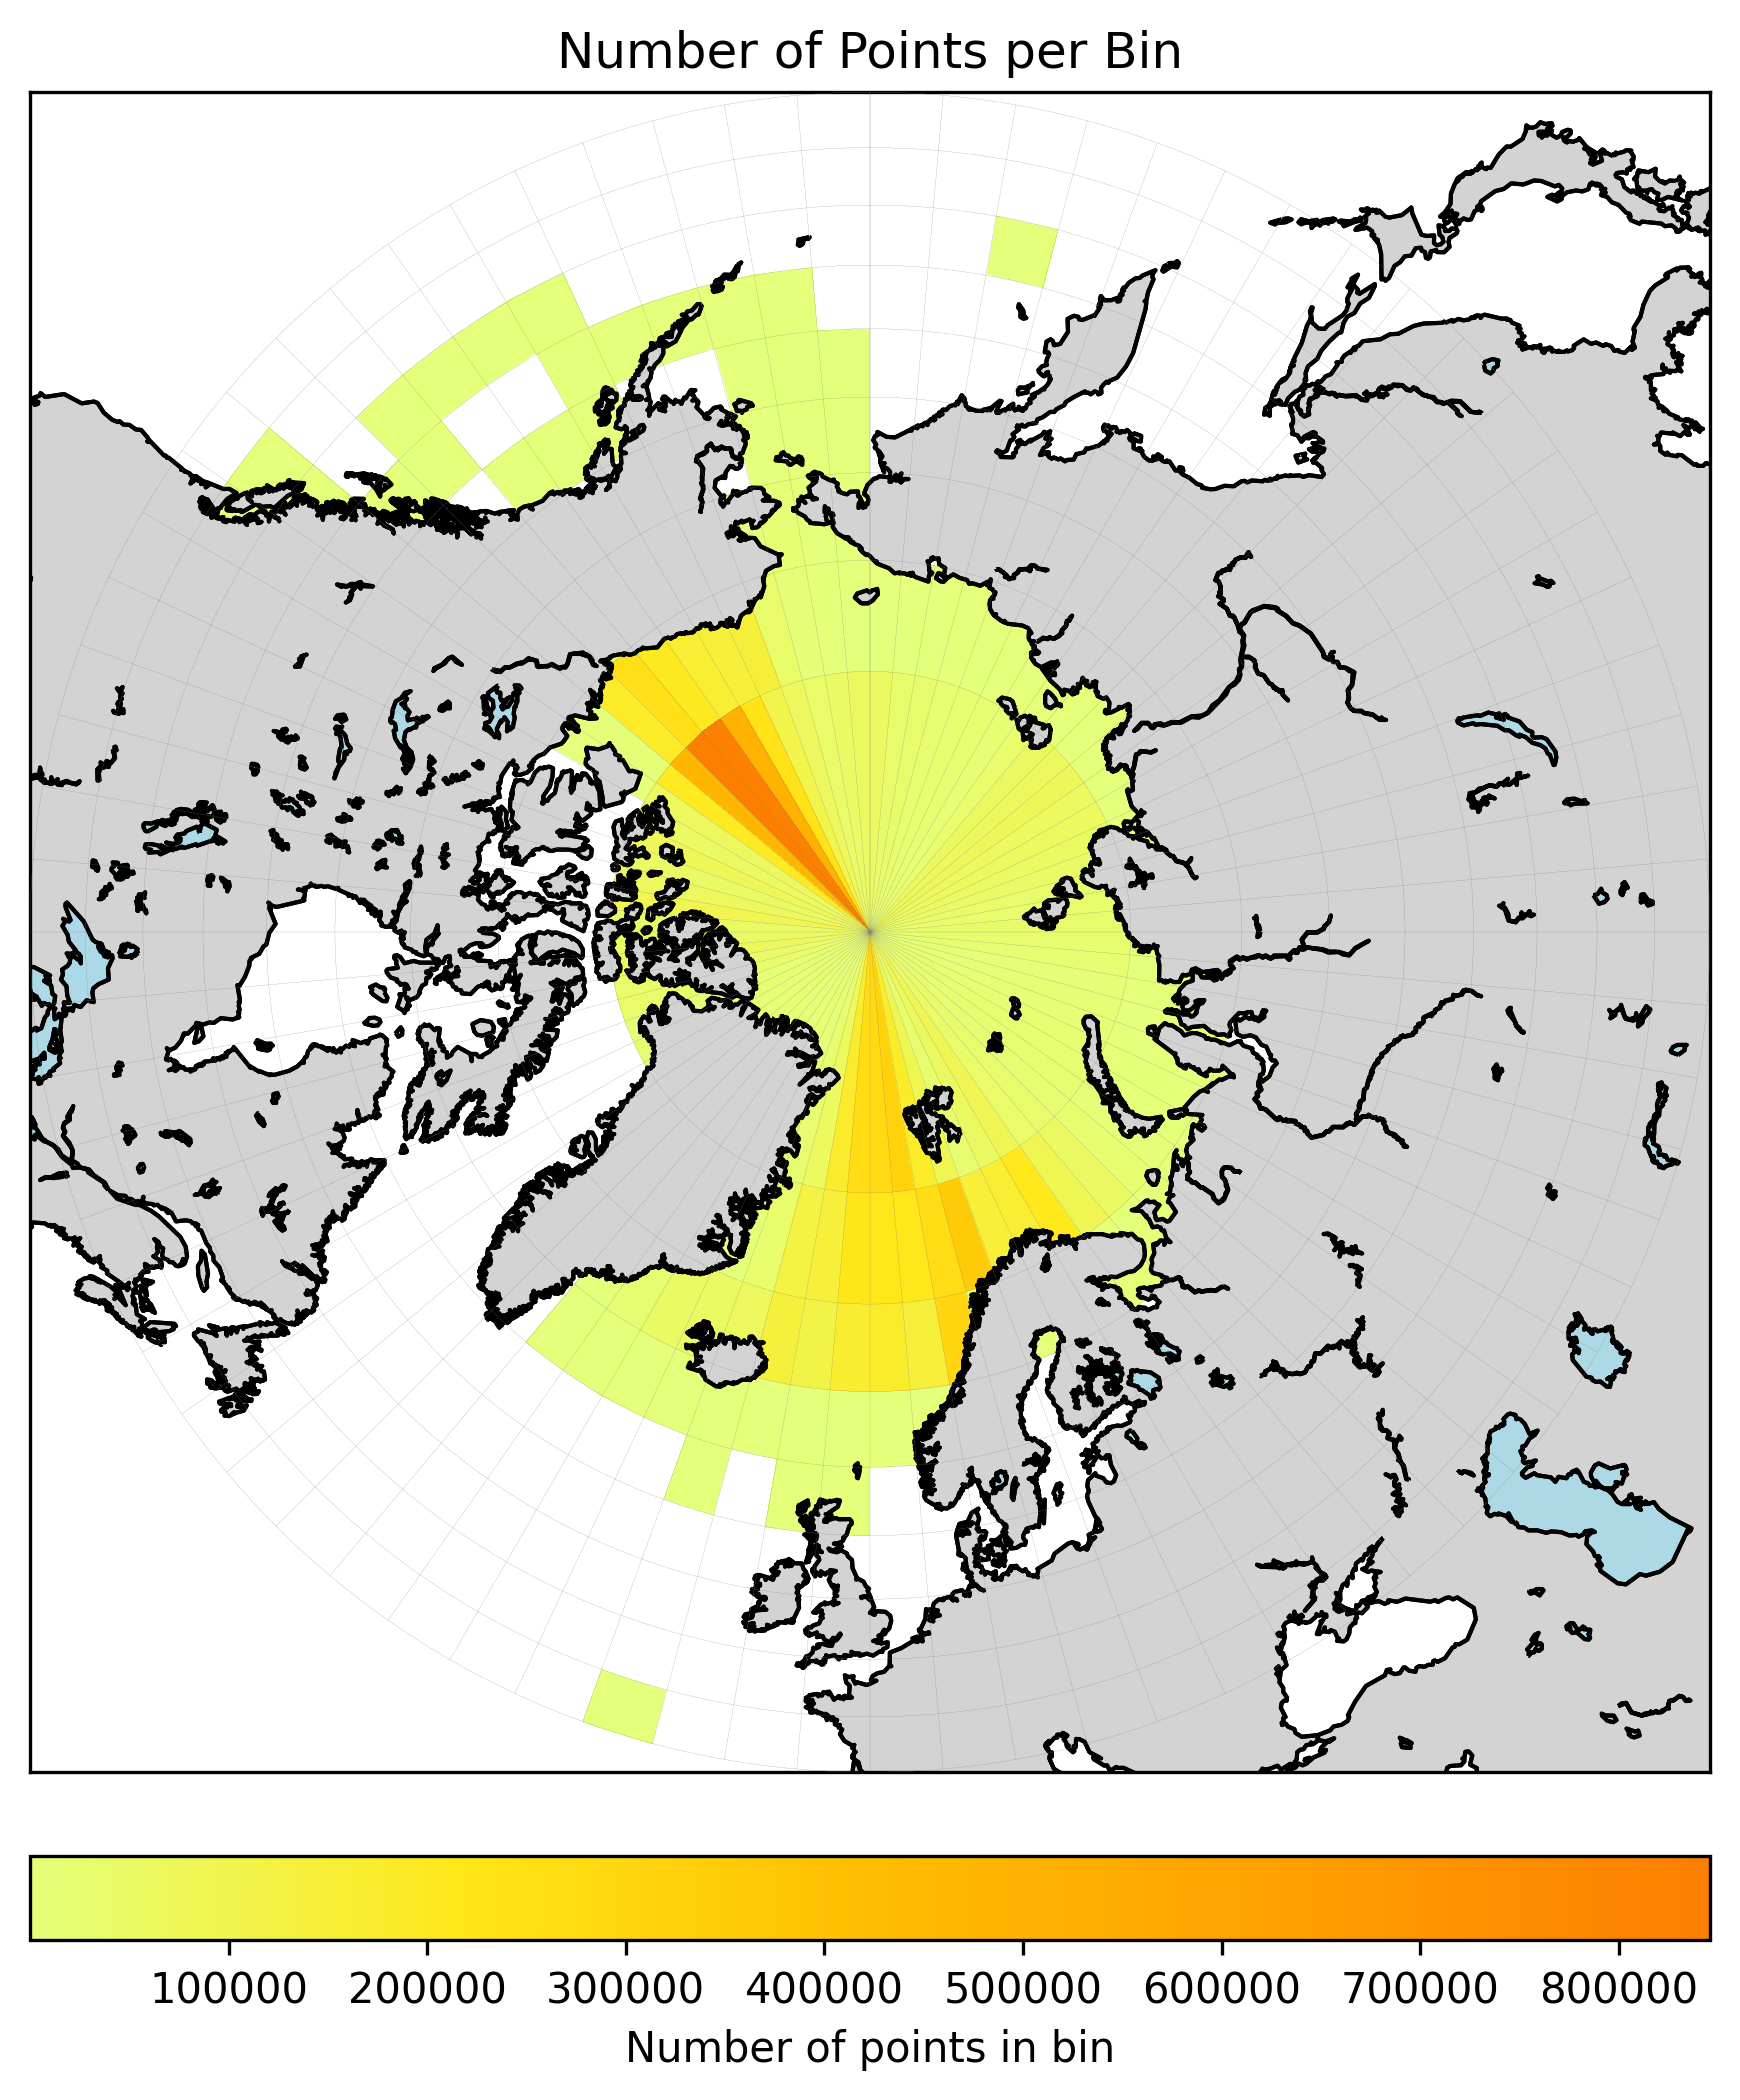

In [52]:
plot_heatmap_npts(df_ST, n_lon_bins=72, n_lat_bins=9)

In [53]:
# find bins with more than 28k points (the transition point at 99% quantile) and save the points in those bins as df
def get_points_bins_over_thresh(df,thresh, n_lon_bins=72, n_lat_bins=9, projection='npstere'):
    # Get lat-lon values
    lat_min = df['Latitude_[deg_N]'].min()
    lon_vals = df['Longitude_[deg_E]'].values
    lat_vals = df['Latitude_[deg_N]'].values

    # Deinfe lat lon bin edges
    lon_bins = np.linspace(-180, 180, n_lon_bins + 1)
    lat_bins = np.linspace(lat_min, 90, n_lat_bins + 1)

    # Digitize points into bins
    lon_idx = np.digitize(lon_vals, lon_bins) - 1
    lat_idx = np.digitize(lat_vals, lat_bins) - 1

    # Count number of profiles per bin
    H = np.zeros((n_lon_bins, n_lat_bins), dtype=int)
    for i in range(len(lon_vals)):
        xi, yi = lon_idx[i], lat_idx[i]
        if 0 <= xi < n_lon_bins and 0 <= yi < n_lat_bins:
            H[xi, yi] += 1

    # Get indices of bins that exceed the threshold
    bins_over_thresh = np.argwhere(H > thresh)

    # Create a mask for points that fall into bins over the threshold
    mask = np.zeros(len(df), dtype=bool)
    for xi, yi in bins_over_thresh:
        mask |= (lon_idx == xi) & (lat_idx == yi)

    # Filter the original dataframe to get points in bins over the threshold
    df_over_thresh = df[mask]

    return df_over_thresh

In [55]:
over_thresh = get_points_bins_over_thresh(df_ST, thresh=200_000, n_lon_bins=72, n_lat_bins=9)

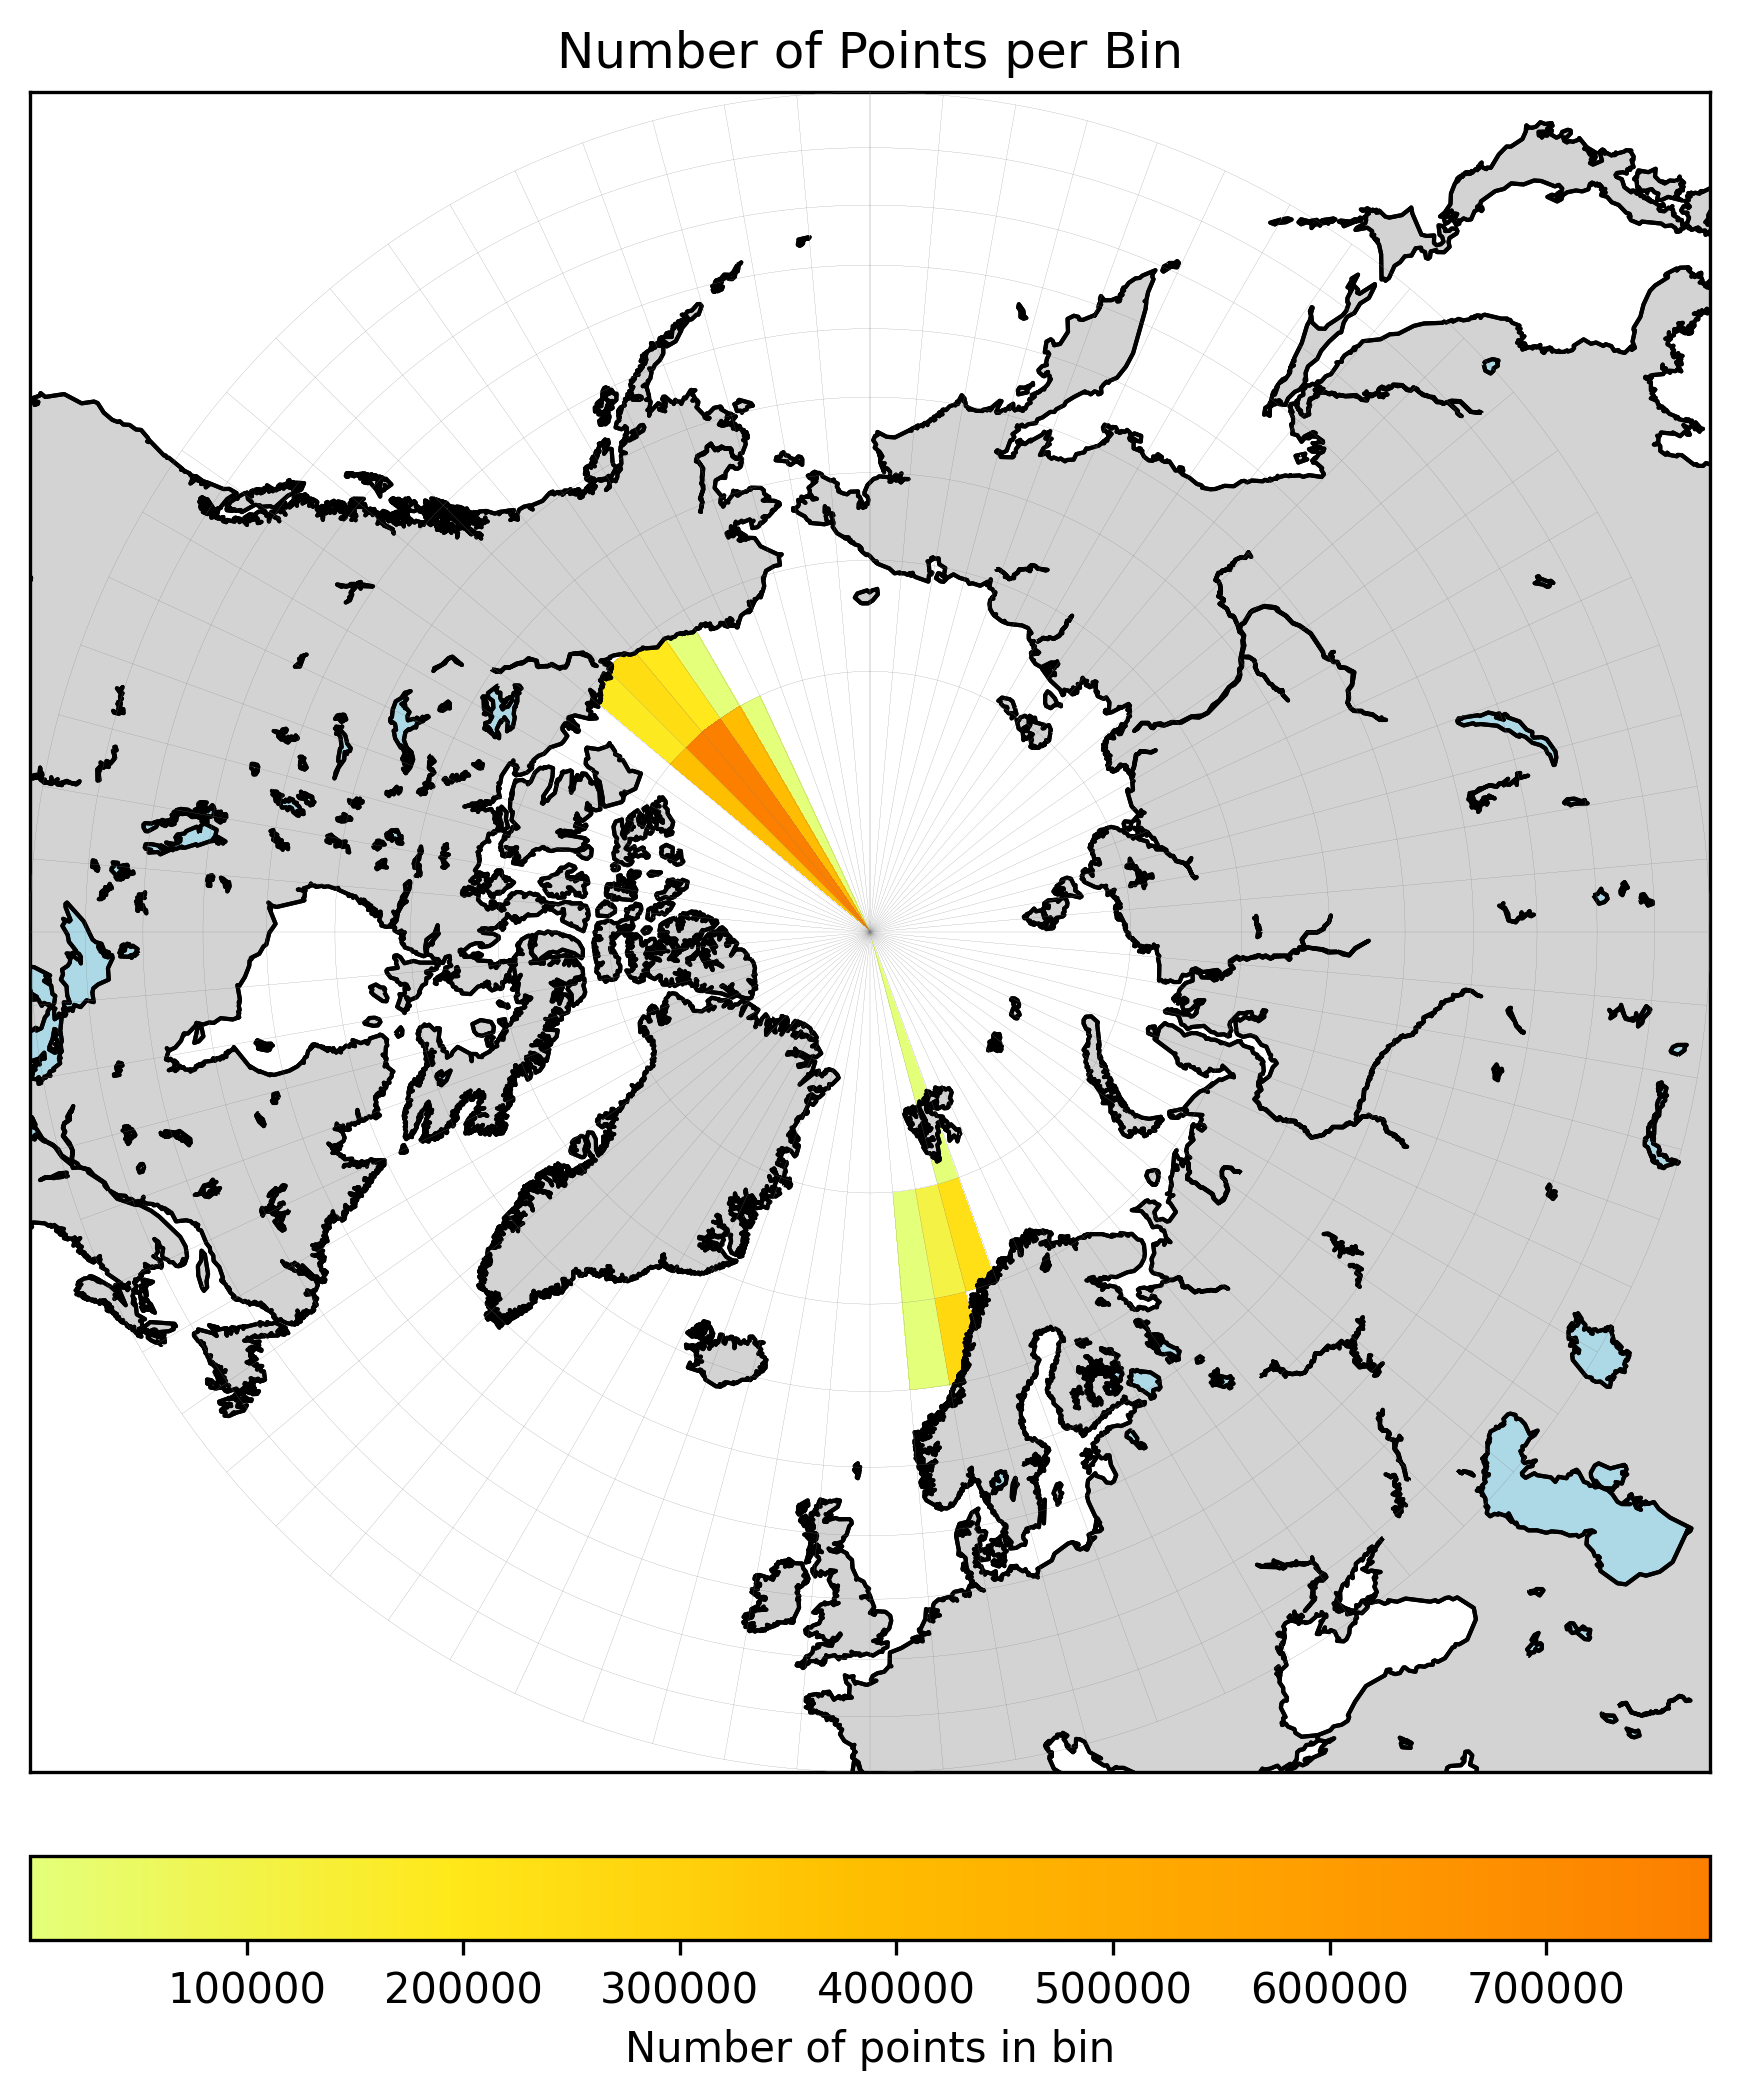

In [56]:
plot_heatmap_npts(over_thresh, n_lon_bins=72, n_lat_bins=9)

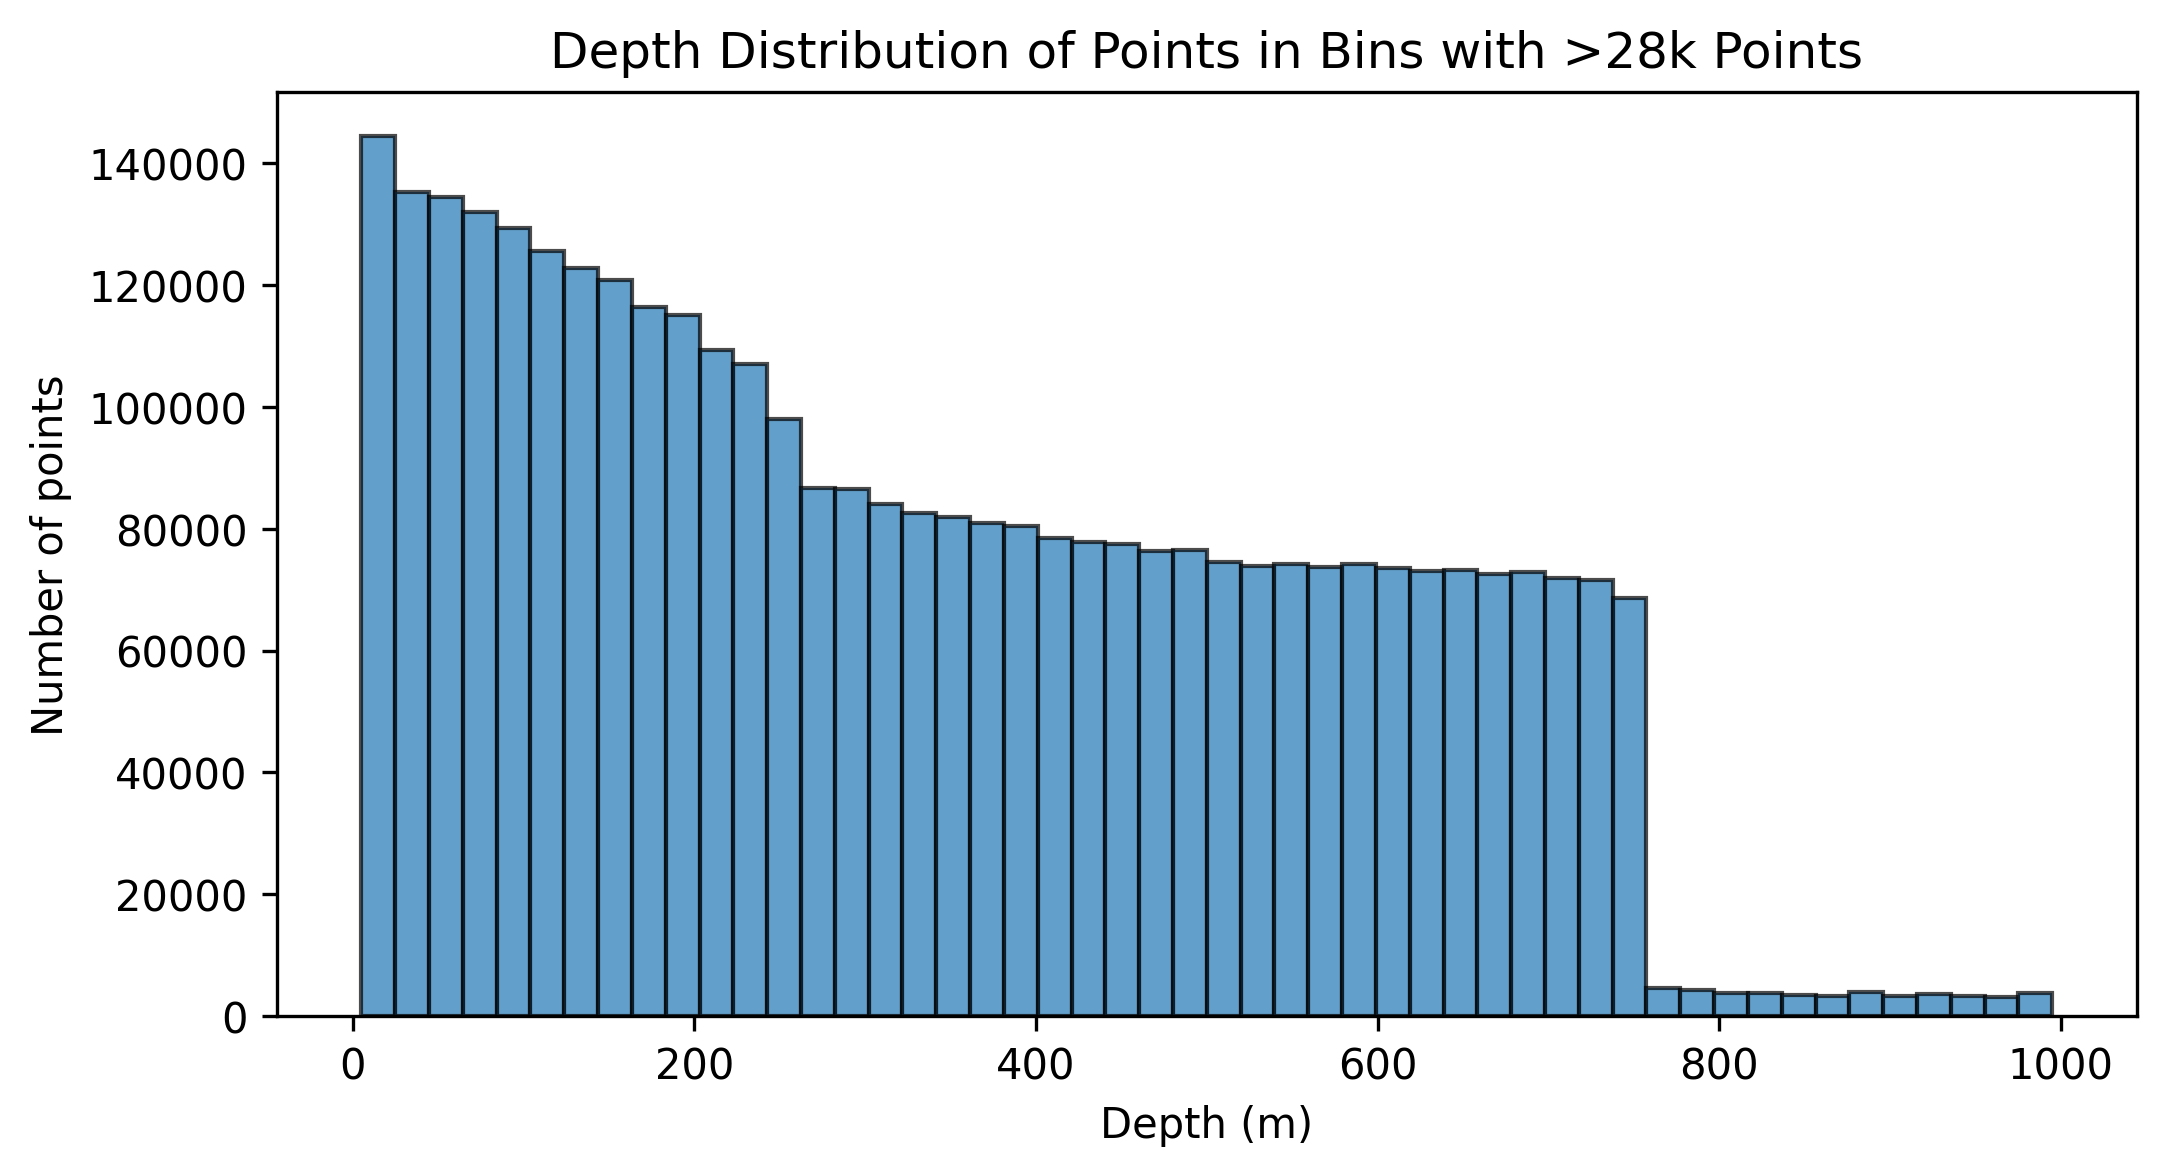

In [57]:
# depth histogram of points in bins over threshold
plt.figure(figsize=(8, 4), dpi=300)
plt.hist(over_thresh['Depth_[m]'], bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Depth (m)')
plt.ylabel('Number of points')
plt.title('Depth Distribution of Points in Bins with >28k Points')
plt.show()

In [58]:
# def sample_cap_bins(df, thresh, n_lon_bins, n_lat_bins):
#     # Define lat lon values
#     lat_min = df['Latitude_[deg_N]'].min()
#     lon_vals = df['Longitude_[deg_E]'].values
#     lat_vals = df['Latitude_[deg_N]'].values

#     # Define lat lon bin edges in projected space
#     lon_bins = np.linspace(lon_vals.min(), lon_vals.max(), n_lon_bins + 1)
#     lat_bins = np.linspace(lat_vals.min(), lat_vals.max(), n_lat_bins + 1)

#     # Assign points to bins and clip edge cases
#     lon_idx = np.clip(np.digitize(lon_vals, lon_bins) - 1, 0, n_lon_bins - 1)
#     lat_idx = np.clip(np.digitize(lat_vals, lat_bins) - 1, 0, n_lat_bins - 1)

#     # Build a dict mapping (xi, yi) -> list of original df indices
#     # This is the single source of truth for bin membership
#     from collections import defaultdict
#     bin_members = defaultdict(list)
#     for i in range(len(lon_vals)):
#         bin_members[(lon_idx[i], lat_idx[i])].append(i)

#     # Sample each bin: cap at thresh if over, keep all if under
#     sampled_indices = []
#     for (xi, yi), members in bin_members.items():
#         if len(members) > thresh:
#             sampled_indices.extend(
#                 np.random.choice(members, size=thresh, replace=False)
#             )
#         else:
#             sampled_indices.extend(members)

#     df_sampled = df.iloc[sampled_indices].copy()
#     return df_sampled

In [72]:
def sample_cap_bins(df, thresh, n_lon_bins, n_lat_bins):
    from collections import defaultdict

    lon_vals = df['Longitude_[deg_E]'].values
    lat_vals = df['Latitude_[deg_N]'].values

    # Define bin edges from the FULL original dataset
    lon_bins = np.linspace(lon_vals.min(), lon_vals.max(), n_lon_bins + 1)
    lat_bins = np.linspace(lat_vals.min(), lat_vals.max(), n_lat_bins + 1)

    # Assign points to bins, clipping edge cases
    lon_idx = np.clip(np.digitize(lon_vals, lon_bins) - 1, 0, n_lon_bins - 1)
    lat_idx = np.clip(np.digitize(lat_vals, lat_bins) - 1, 0, n_lat_bins - 1)

    # Build bin membership dict
    bin_members = defaultdict(list)
    for i in range(len(lon_vals)):
        bin_members[(lon_idx[i], lat_idx[i])].append(i)

    # Cap each bin at thresh
    sampled_indices = []
    for (xi, yi), members in bin_members.items():
        if len(members) > thresh:
            sampled_indices.extend(
                np.random.choice(members, size=thresh, replace=False).tolist()
            )
        else:
            sampled_indices.extend(members)

    df_sampled = df.iloc[sampled_indices].copy()

    # Return bin edges alongside the sampled dataframe
    return df_sampled, lon_bins, lat_bins

In [74]:
df_sampled,_,_ = sample_cap_bins(df_ST, thresh=200_000, n_lon_bins=72, n_lat_bins=9)

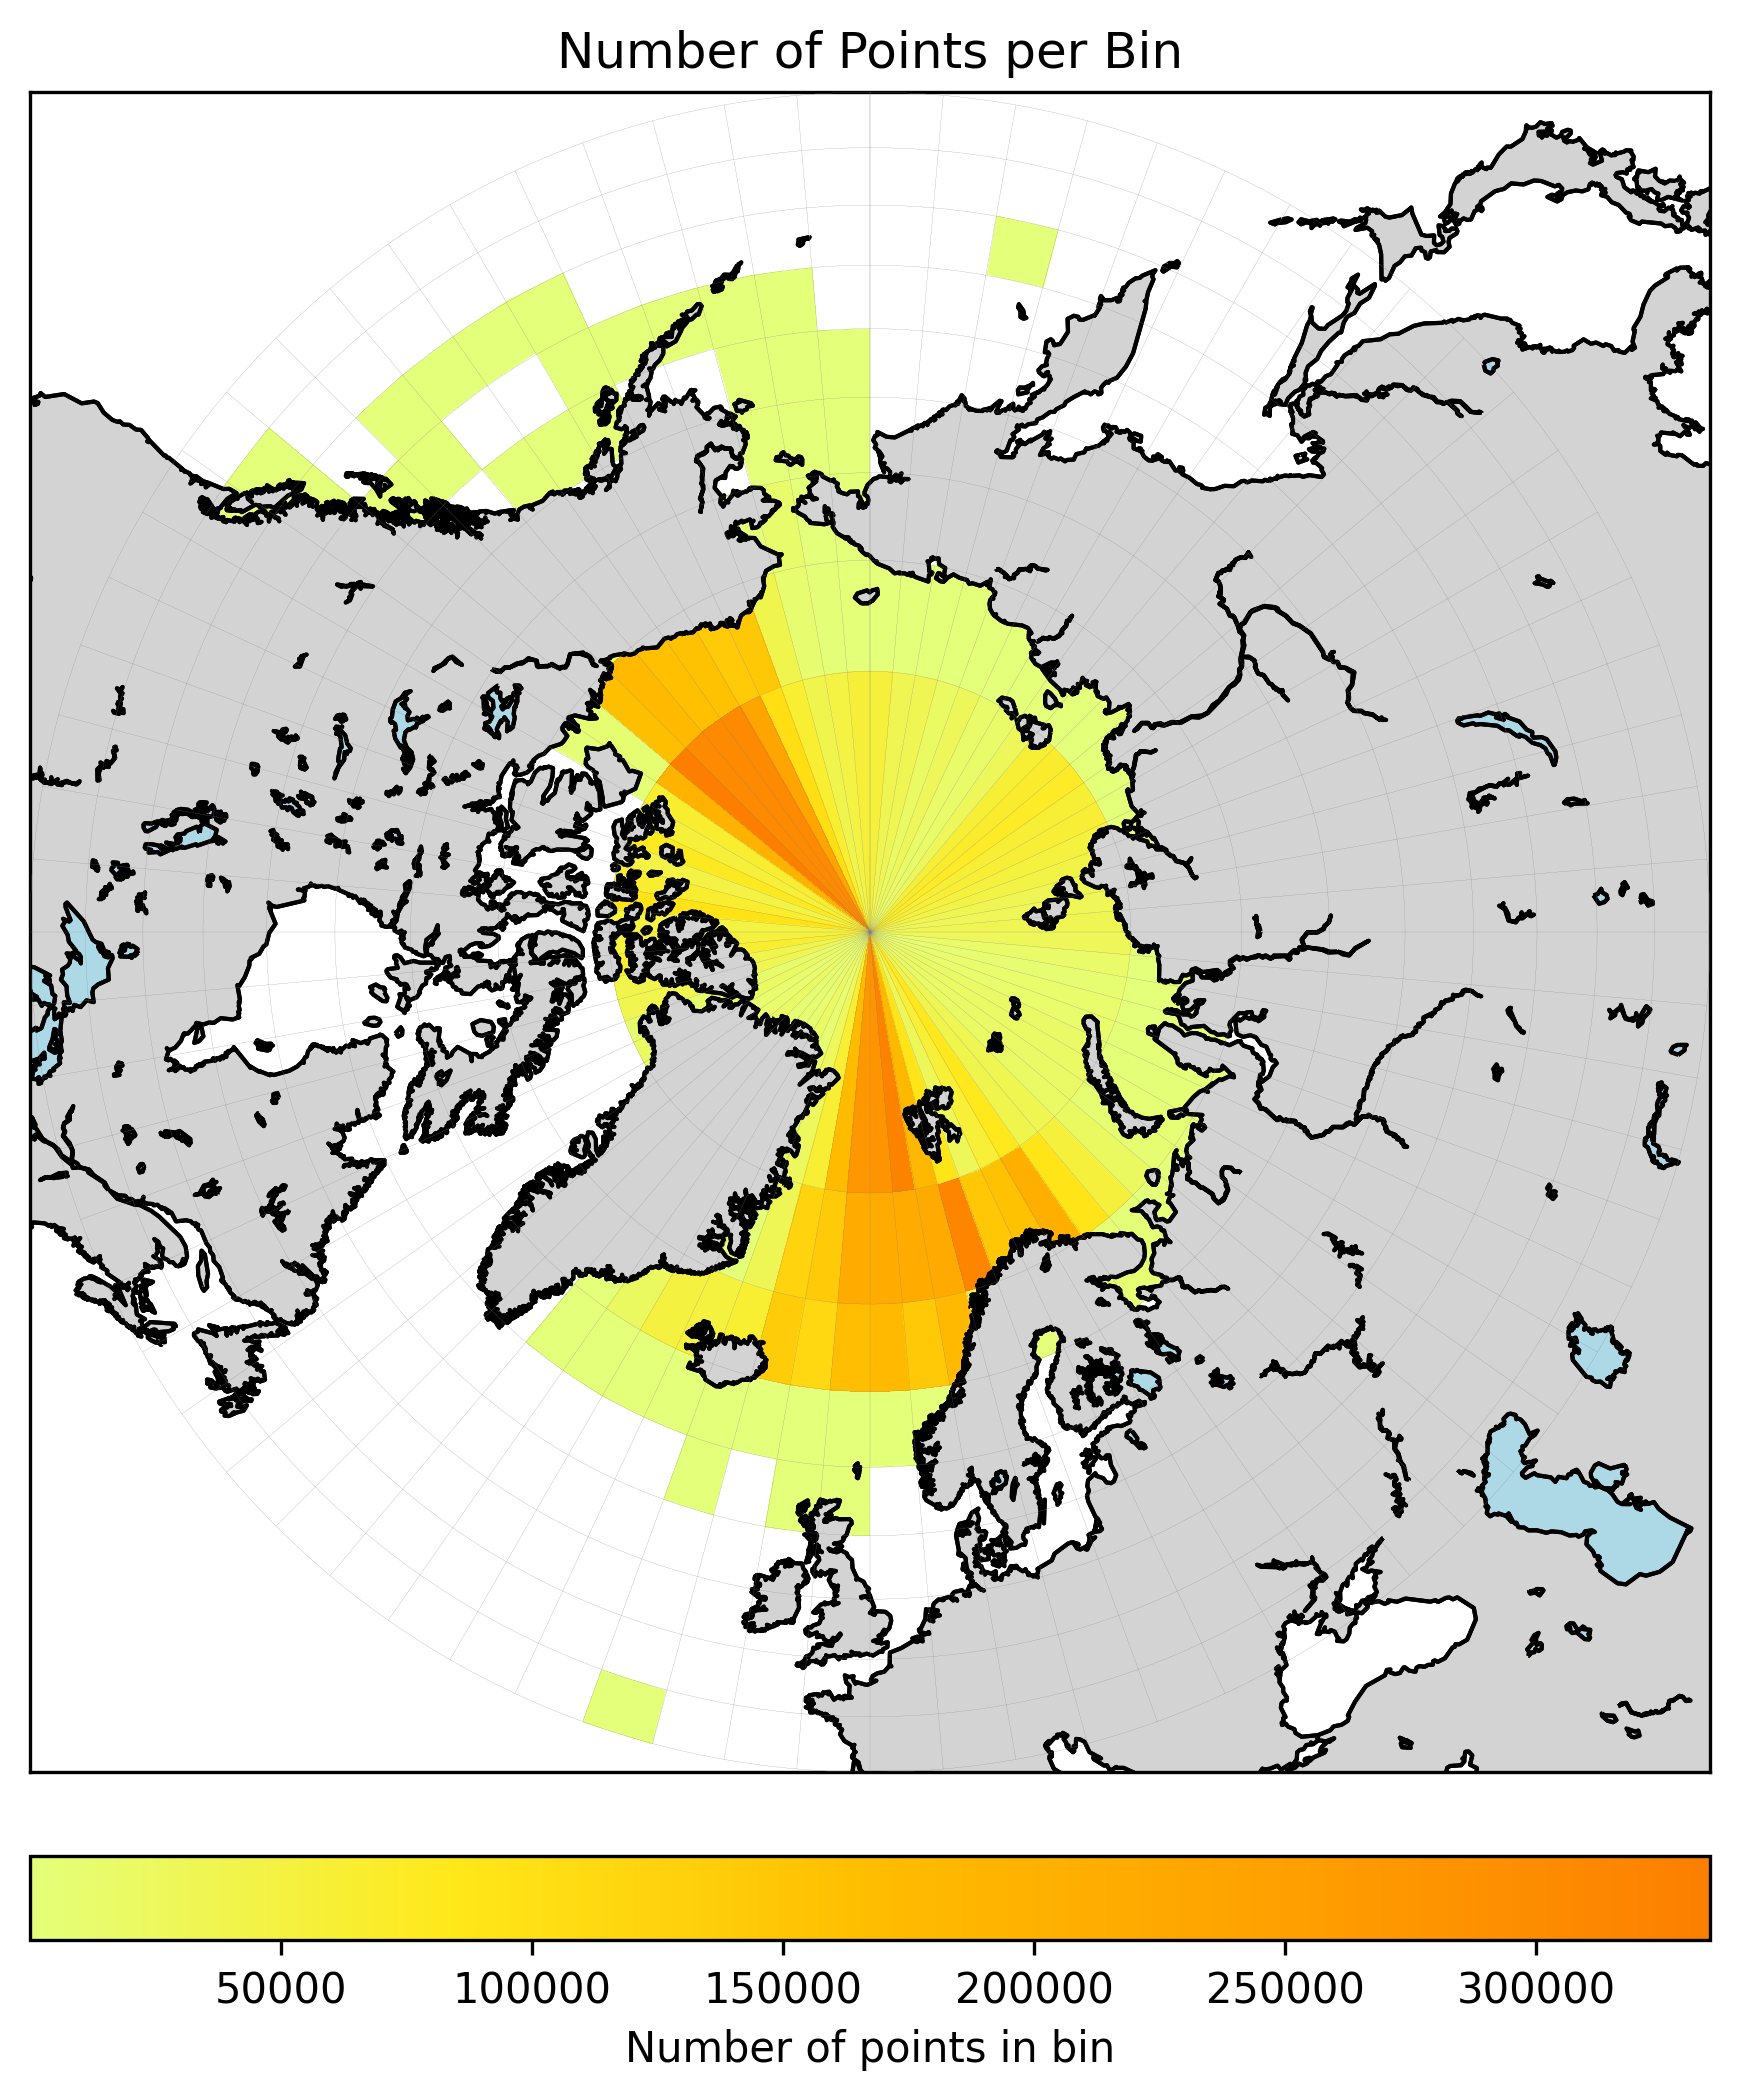

In [75]:
plot_heatmap_npts(df_sampled, n_lon_bins=72, n_lat_bins=9)

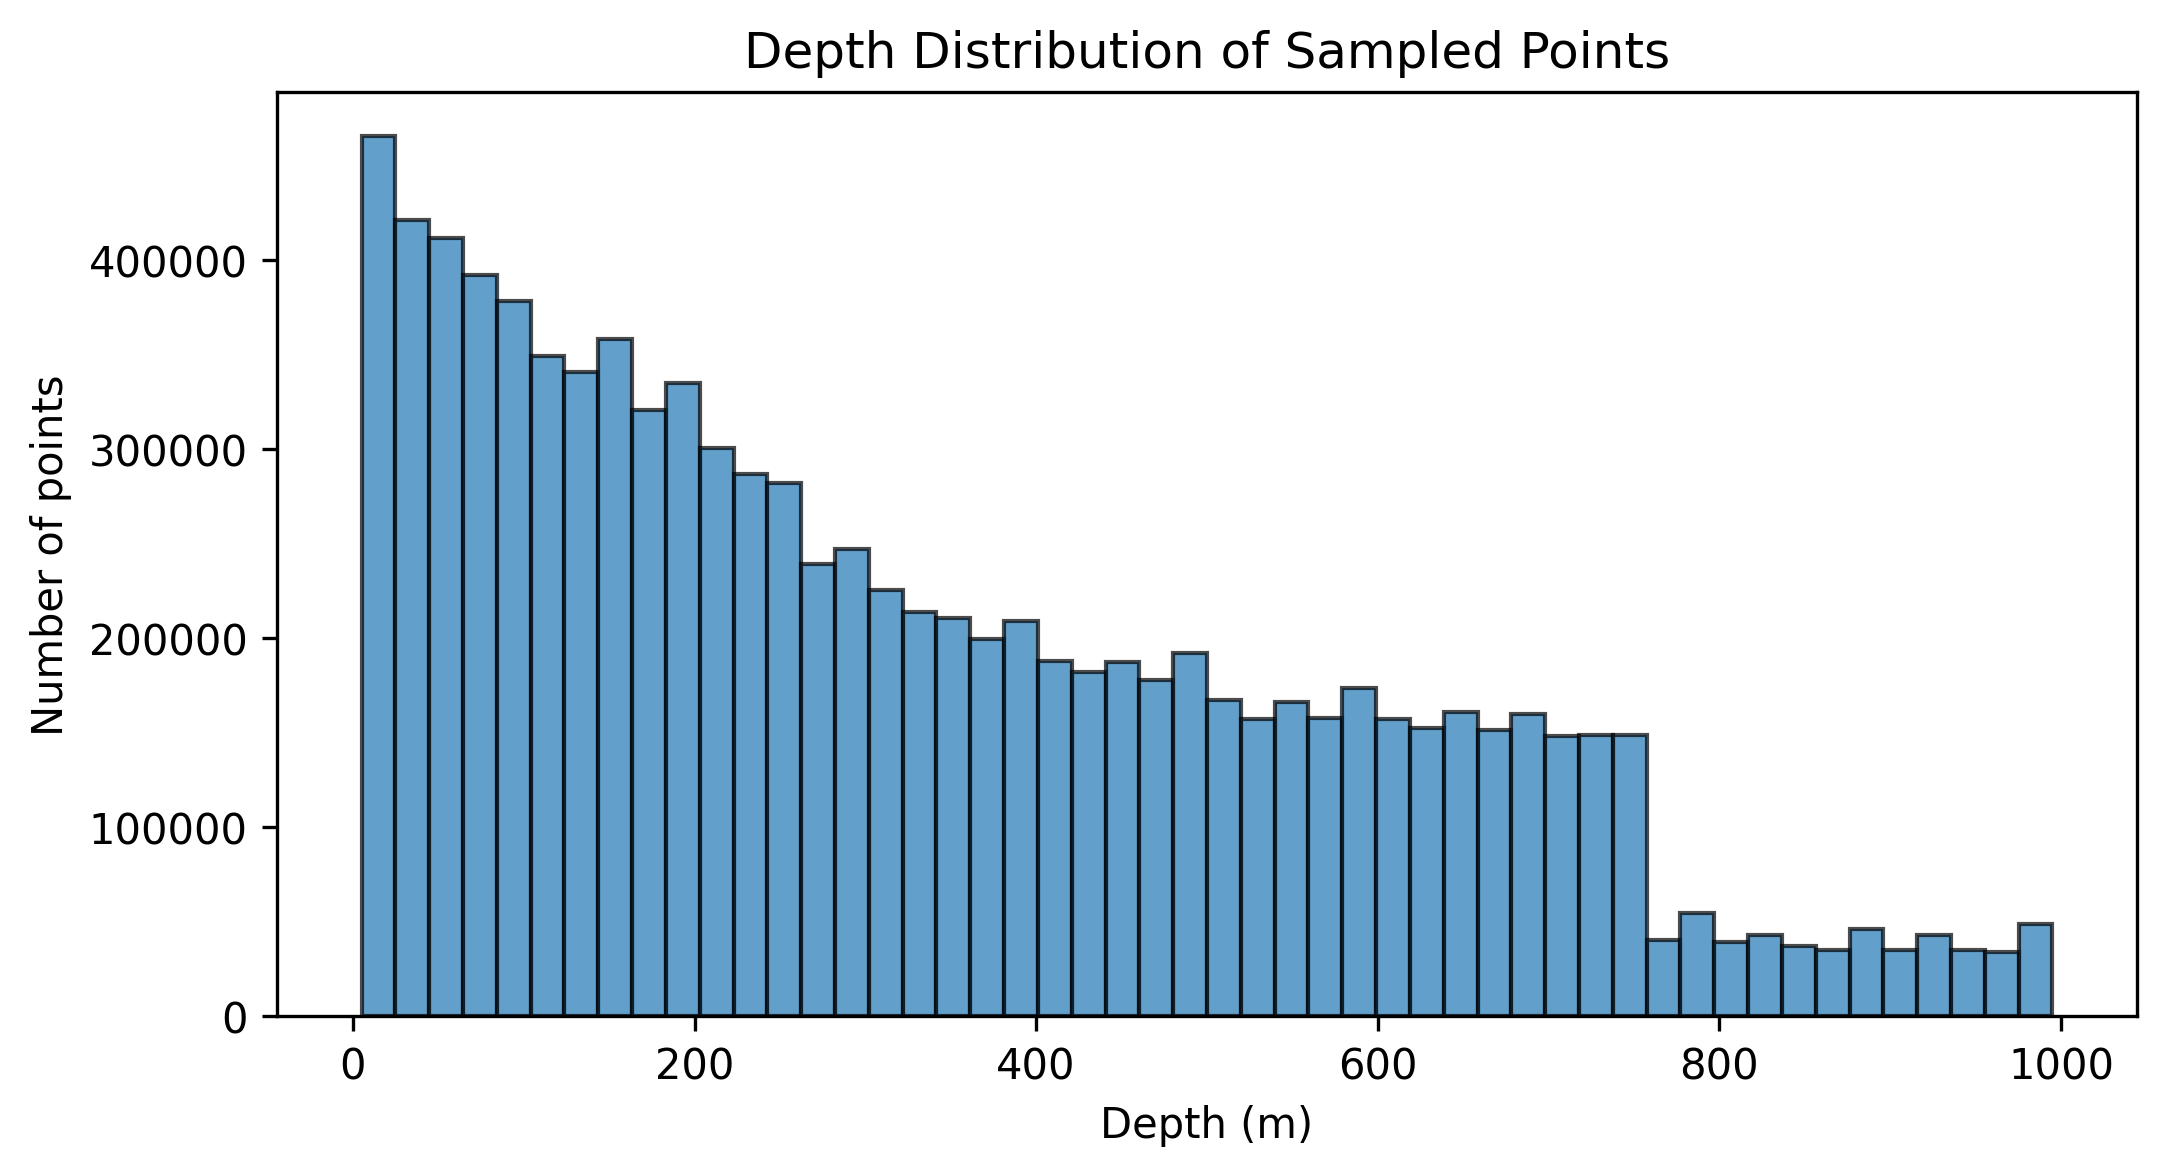

In [69]:
# Depth histogram of sampled dataframe
plt.figure(figsize=(8, 4), dpi=300)
plt.hist(df_sampled['Depth_[m]'], bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Depth (m)')
plt.ylabel('Number of points')
plt.title('Depth Distribution of Sampled Points')
plt.show()

In [71]:
profileNo_vs_latlon_bins(df_sampled, lat_step=5, lon_step=5, show_threshold=True, threshold_quantile=0.99)

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_38717/1342144697.py:26: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [9]:
def plot_heatmap_npts_xy(ds_cleaned, n_x_bins=100, n_y_bins=100, bin_max=None, projection='npstere', projection_name='Polar Stereographic'):
    lat_min = ds_cleaned['Latitude_[deg_N]'].min()
    resolution = 'l'

    fig = plt.figure(figsize=(8, 8), dpi=300)
    m = Basemap(projection=projection, boundinglat=lat_min, lon_0=0, resolution=resolution)

    # Convert lat/lon → x/y (projection coordinates in meters)
    lon_vals = ds_cleaned['Longitude_[deg_E]'].values
    lat_vals = ds_cleaned['Latitude_[deg_N]'].values

    # Reproject lat/lon to x/y
    x_vals, y_vals = m(lon_vals, lat_vals)

    # Define XY bin edges
    x_min, x_max = x_vals.min(), x_vals.max()
    y_min, y_max = y_vals.min(), y_vals.max()

    x_bins = np.linspace(x_min, x_max, n_x_bins + 1)
    y_bins = np.linspace(y_min, y_max, n_y_bins + 1)

    # Grid to store max depth
    H = np.zeros((n_x_bins, n_y_bins))

    # Digitize into bins
    x_idx = np.digitize(x_vals, x_bins) - 1
    y_idx = np.digitize(y_vals, y_bins) - 1

    # Count number of points in each bin
    for i in range(len(x_vals)):
        xi, yi = x_idx[i], y_idx[i]
        if 0 <= xi < n_x_bins and 0 <= yi < n_y_bins:
            H[xi, yi] += 1

    # Create meshgrid for plotting
    X, Y = np.meshgrid(x_bins, y_bins)

    # Colormap
    cmap = plt.get_cmap('Wistia').copy()
    cmap.set_under(color='white', alpha=1.0)
    cmap.set_over(color='white', alpha=1.0)

    if bin_max is None:
        bin_max = H.max()

    # Plot heatmap
    m.pcolormesh(X, Y, H.T, cmap=cmap, vmin=1, vmax=bin_max)

    # Draw bin grid (in xy space)
    for xb in x_bins:
        plt.plot([xb]*len(y_bins), y_bins, color='grey', linewidth=0.05, zorder=3)
    for yb in y_bins:
        plt.plot(x_bins, [yb]*len(x_bins), color='grey', linewidth=0.05, zorder=3)

    # Plot coastlines on top
    m.drawcoastlines()
    m.fillcontinents(color='lightgrey', lake_color='lightblue')

    cbar = m.colorbar(location='bottom', pad="5%")
    cbar.set_label('Number of points per bin')

    plt.xticks([])
    plt.yticks([])
    plt.title('Number of Points per Bin in '+ f'({projection_name} Projection)')

    plt.show()

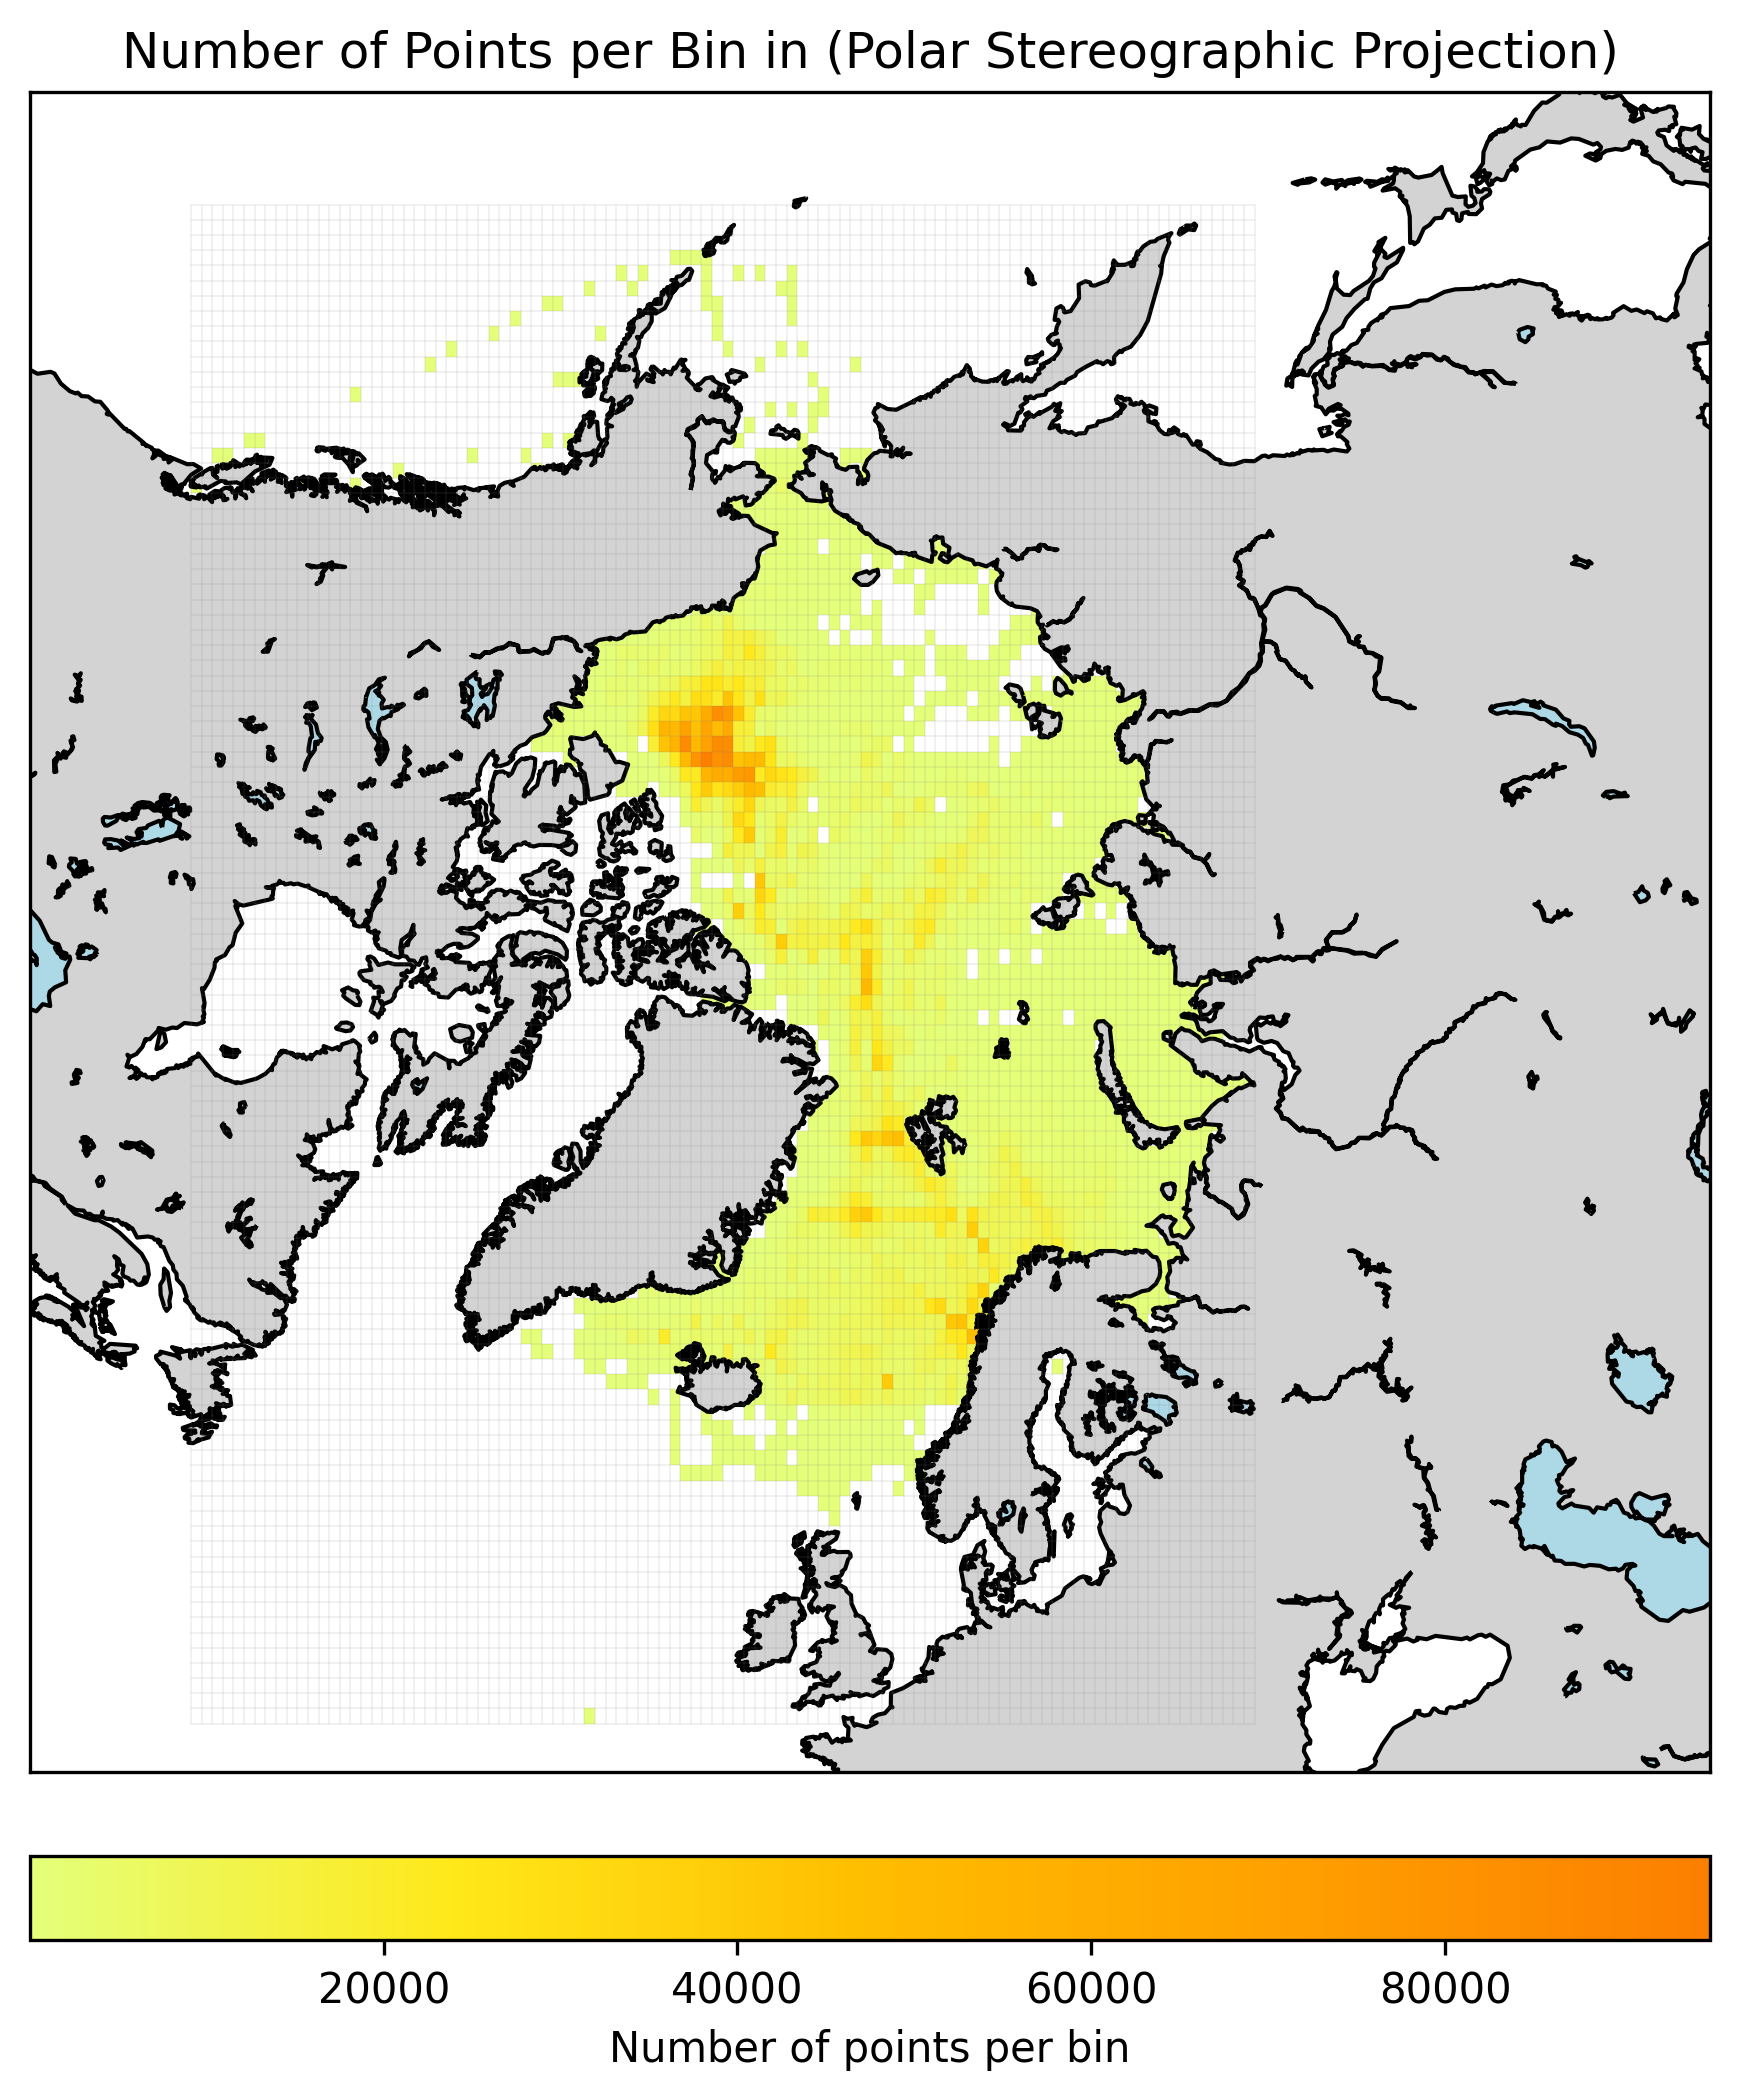

In [10]:
plot_heatmap_npts_xy(df_ST, n_x_bins=100, n_y_bins=100, projection='npstere', projection_name='Polar Stereographic')

In [12]:
def profileNo_vs_xy_bins(
    df: pd.DataFrame,
    n_x_bins: int = 100,
    n_y_bins: int = 100,
    show_threshold: bool = False,
    threshold_quantile: float = 0.95,
    projection: str = 'npstere'
) -> None:
    """
    Plot the number of profiles in each bin using polar stereographic projection.
    Args:
        df (pd.DataFrame): The dataset to plot.
        n_x_bins (int): Number of bins in the x direction. Defaults to 100.
        n_y_bins (int): Number of bins in the y direction. Defaults to 100.
        show_threshold (bool, optional): Whether to show the threshold marker. Defaults to False.
        threshold_quantile (float, optional): The quantile value for threshold calculation. Defaults to 0.95.
        projection (str, optional): Basemap projection string. Defaults to 'npstere'.
    Returns:
        None
    """
    # Set up the polar stereographic projection
    lat_min = df['Latitude_[deg_N]'].min()
    m = Basemap(projection=projection, boundinglat=lat_min, lon_0=0, resolution='l')

    # Reproject lat/lon to x/y (projection coordinates in metres)
    lon_vals = df['Longitude_[deg_E]'].values
    lat_vals = df['Latitude_[deg_N]'].values
    x_vals, y_vals = m(lon_vals, lat_vals)

    # Define XY bin edges in projected space
    x_min, x_max = x_vals.min(), x_vals.max()
    y_min, y_max = y_vals.min(), y_vals.max()
    x_bins = np.linspace(x_min, x_max, n_x_bins + 1)
    y_bins = np.linspace(y_min, y_max, n_y_bins + 1)

    # Digitize points into bins
    x_idx = np.digitize(x_vals, x_bins) - 1
    y_idx = np.digitize(y_vals, y_bins) - 1

    # Count number of profiles per bin
    H = np.zeros((n_x_bins, n_y_bins), dtype=int)
    for i in range(len(x_vals)):
        xi, yi = x_idx[i], y_idx[i]
        if 0 <= xi < n_x_bins and 0 <= yi < n_y_bins:
            H[xi, yi] += 1

    # Flatten to get non-zero bin counts (matching original behaviour of only counting occupied bins)
    g_len = H[H > 0].flatten().tolist()
    g_len_sorted = sorted(g_len)

    # Threshold / transition point detection
    transition_point = None
    if len(g_len_sorted) > 1:
        g_len_diff = np.diff(g_len_sorted)
        threshold = np.quantile(g_len_diff, threshold_quantile)
        for i in range(1, len(g_len_sorted)):
            if g_len_sorted[i] - g_len_sorted[i - 1] > threshold:
                transition_point = i - 1
                break

    # Build Plotly traces
    trace = go.Scatter(
        x=list(range(len(g_len_sorted))),
        y=g_len_sorted
    )

    if show_threshold and transition_point is not None:
        red_dot = go.Scatter(
            x=[transition_point],
            y=[g_len_sorted[transition_point]],
            mode='markers',
            marker=dict(color='red', size=10)
        )
        fig_data = [trace, red_dot]
    else:
        fig_data = [trace]

    layout = go.Layout(
        xaxis=dict(title='Bin No.'),
        yaxis=dict(title='Number of points per bin')
    )
    fig = go.Figure(data=fig_data, layout=layout)
    fig.show()

In [14]:
profileNo_vs_xy_bins(df_ST, n_x_bins=100, n_y_bins=100, show_threshold=True, threshold_quantile=0.95, projection='npstere')

In [15]:
profileNo_vs_xy_bins(df_ST, n_x_bins=100, n_y_bins=100, show_threshold=True, threshold_quantile=0.99, projection='npstere')

In [19]:
# find bins with more than 28k points (the transition point at 99% quantile) and save the points in those bins as df
def get_points_bins_over_thresh_xy(df,thresh, n_x_bins=100, n_y_bins=100, projection='npstere'):
    lat_min = df['Latitude_[deg_N]'].min()
    m = Basemap(projection=projection, boundinglat=lat_min, lon_0=0, resolution='l')

    # Reproject lat/lon to x/y (projection coordinates in metres)
    lon_vals = df['Longitude_[deg_E]'].values
    lat_vals = df['Latitude_[deg_N]'].values
    x_vals, y_vals = m(lon_vals, lat_vals)

    # Define XY bin edges in projected space
    x_min, x_max = x_vals.min(), x_vals.max()
    y_min, y_max = y_vals.min(), y_vals.max()
    x_bins = np.linspace(x_min, x_max, n_x_bins + 1)
    y_bins = np.linspace(y_min, y_max, n_y_bins + 1)

    # Digitize points into bins
    x_idx = np.digitize(x_vals, x_bins) - 1
    y_idx = np.digitize(y_vals, y_bins) - 1

    # Count number of profiles per bin
    H = np.zeros((n_x_bins, n_y_bins), dtype=int)
    for i in range(len(x_vals)):
        xi, yi = x_idx[i], y_idx[i]
        if 0 <= xi < n_x_bins and 0 <= yi < n_y_bins:
            H[xi, yi] += 1

    # Get indices of bins that exceed the threshold
    bins_over_thresh = np.argwhere(H > thresh)

    # Create a mask for points that fall into bins over the threshold
    mask = np.zeros(len(df), dtype=bool)
    for xi, yi in bins_over_thresh:
        mask |= (x_idx == xi) & (y_idx == yi)

    # Filter the original dataframe to get points in bins over the threshold
    df_over_thresh = df[mask]

    return df_over_thresh

In [20]:
df_over_thresh = get_points_bins_over_thresh_xy(df_ST, thresh=28000)

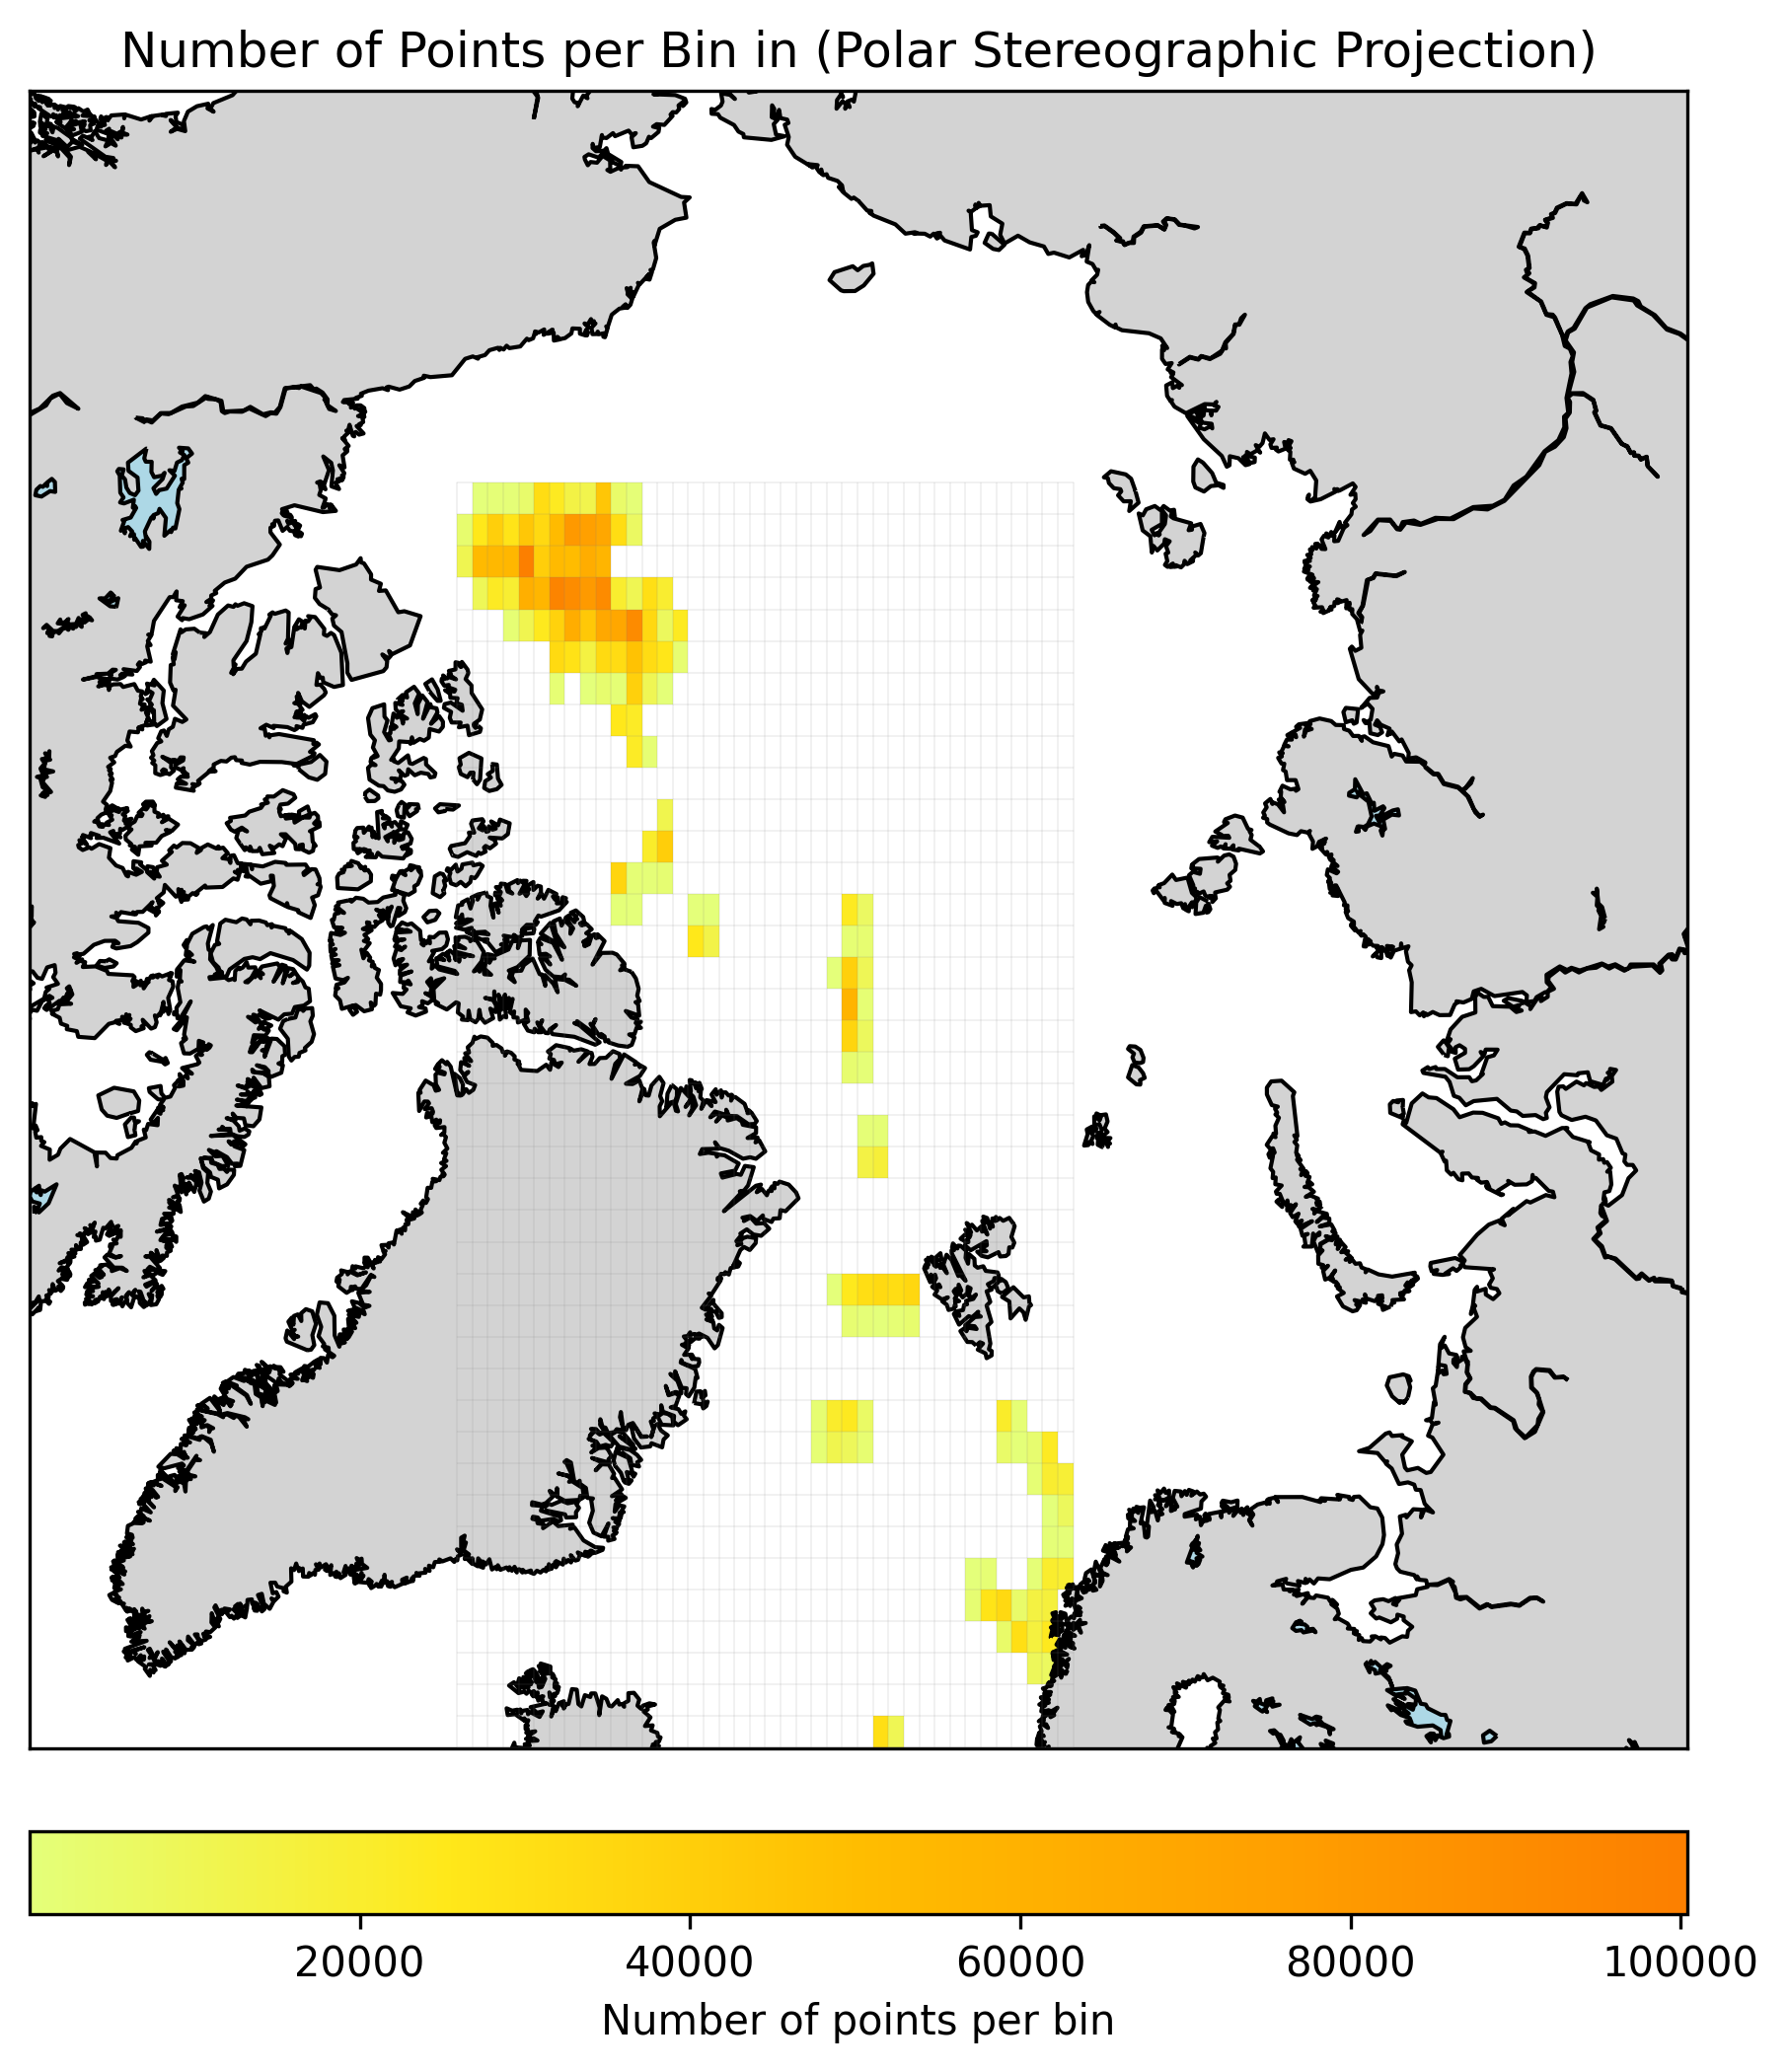

In [29]:
plot_heatmap_npts_xy(df_over_thresh, n_x_bins=40, n_y_bins=40, projection='npstere', projection_name='Polar Stereographic')

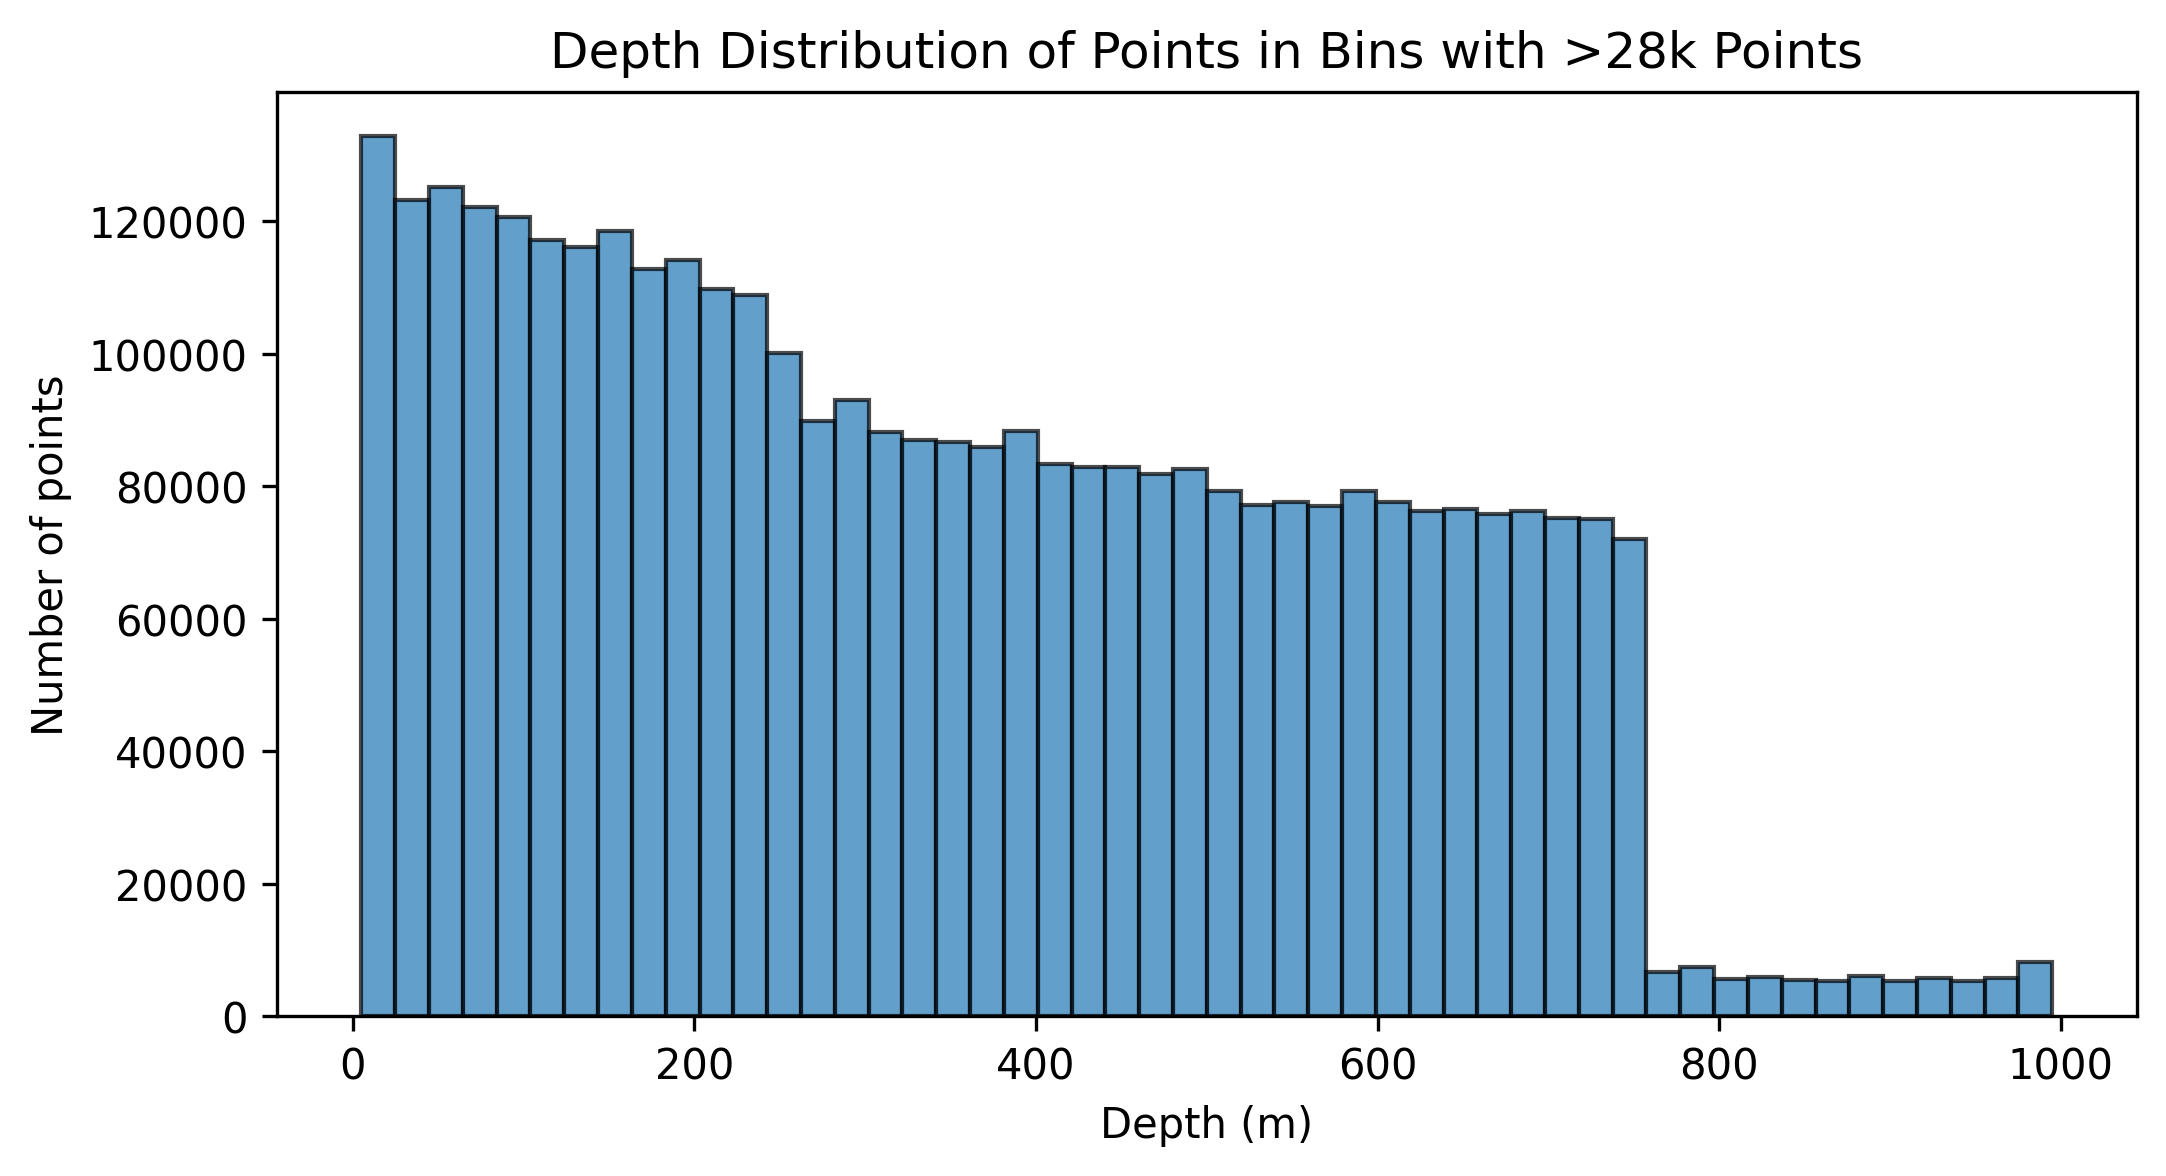

In [34]:
# depth histogram of points in bins over threshold
plt.figure(figsize=(8, 4), dpi=300)
plt.hist(df_over_thresh['Depth_[m]'], bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Depth (m)')
plt.ylabel('Number of points')
plt.title('Depth Distribution of Points in Bins with >28k Points')
plt.show()

In [44]:
def sample_cap_bins_xy(df, thresh, n_x_bins, n_y_bins):
    # Define projection and reproject lat/lon to x/y
    lat_min = df['Latitude_[deg_N]'].min()
    m = Basemap(projection='npstere', boundinglat=lat_min, lon_0=0, resolution='l')
    lon_vals = df['Longitude_[deg_E]'].values
    lat_vals = df['Latitude_[deg_N]'].values
    x_vals, y_vals = m(lon_vals, lat_vals)

    # Define XY bin edges in projected space
    x_bins = np.linspace(x_vals.min(), x_vals.max(), n_x_bins + 1)
    y_bins = np.linspace(y_vals.min(), y_vals.max(), n_y_bins + 1)

    # Assign points to bins and clip edge cases
    x_idx = np.clip(np.digitize(x_vals, x_bins) - 1, 0, n_x_bins - 1)
    y_idx = np.clip(np.digitize(y_vals, y_bins) - 1, 0, n_y_bins - 1)

    # Build a dict mapping (xi, yi) -> list of original df indices
    # This is the single source of truth for bin membership
    from collections import defaultdict
    bin_members = defaultdict(list)
    for i in range(len(x_vals)):
        bin_members[(x_idx[i], y_idx[i])].append(i)

    # Sample each bin: cap at thresh if over, keep all if under
    sampled_indices = []
    for (xi, yi), members in bin_members.items():
        if len(members) > thresh:
            sampled_indices.extend(
                np.random.choice(members, size=thresh, replace=False)
            )
        else:
            sampled_indices.extend(members)

    df_sampled = df.iloc[sampled_indices].copy()
    return df_sampled

In [45]:
# Sample points in bins over threshold to cap at 28k points
df_sampled = sample_cap_bins_xy(df_ST, thresh=28000, n_x_bins=100, n_y_bins=100)

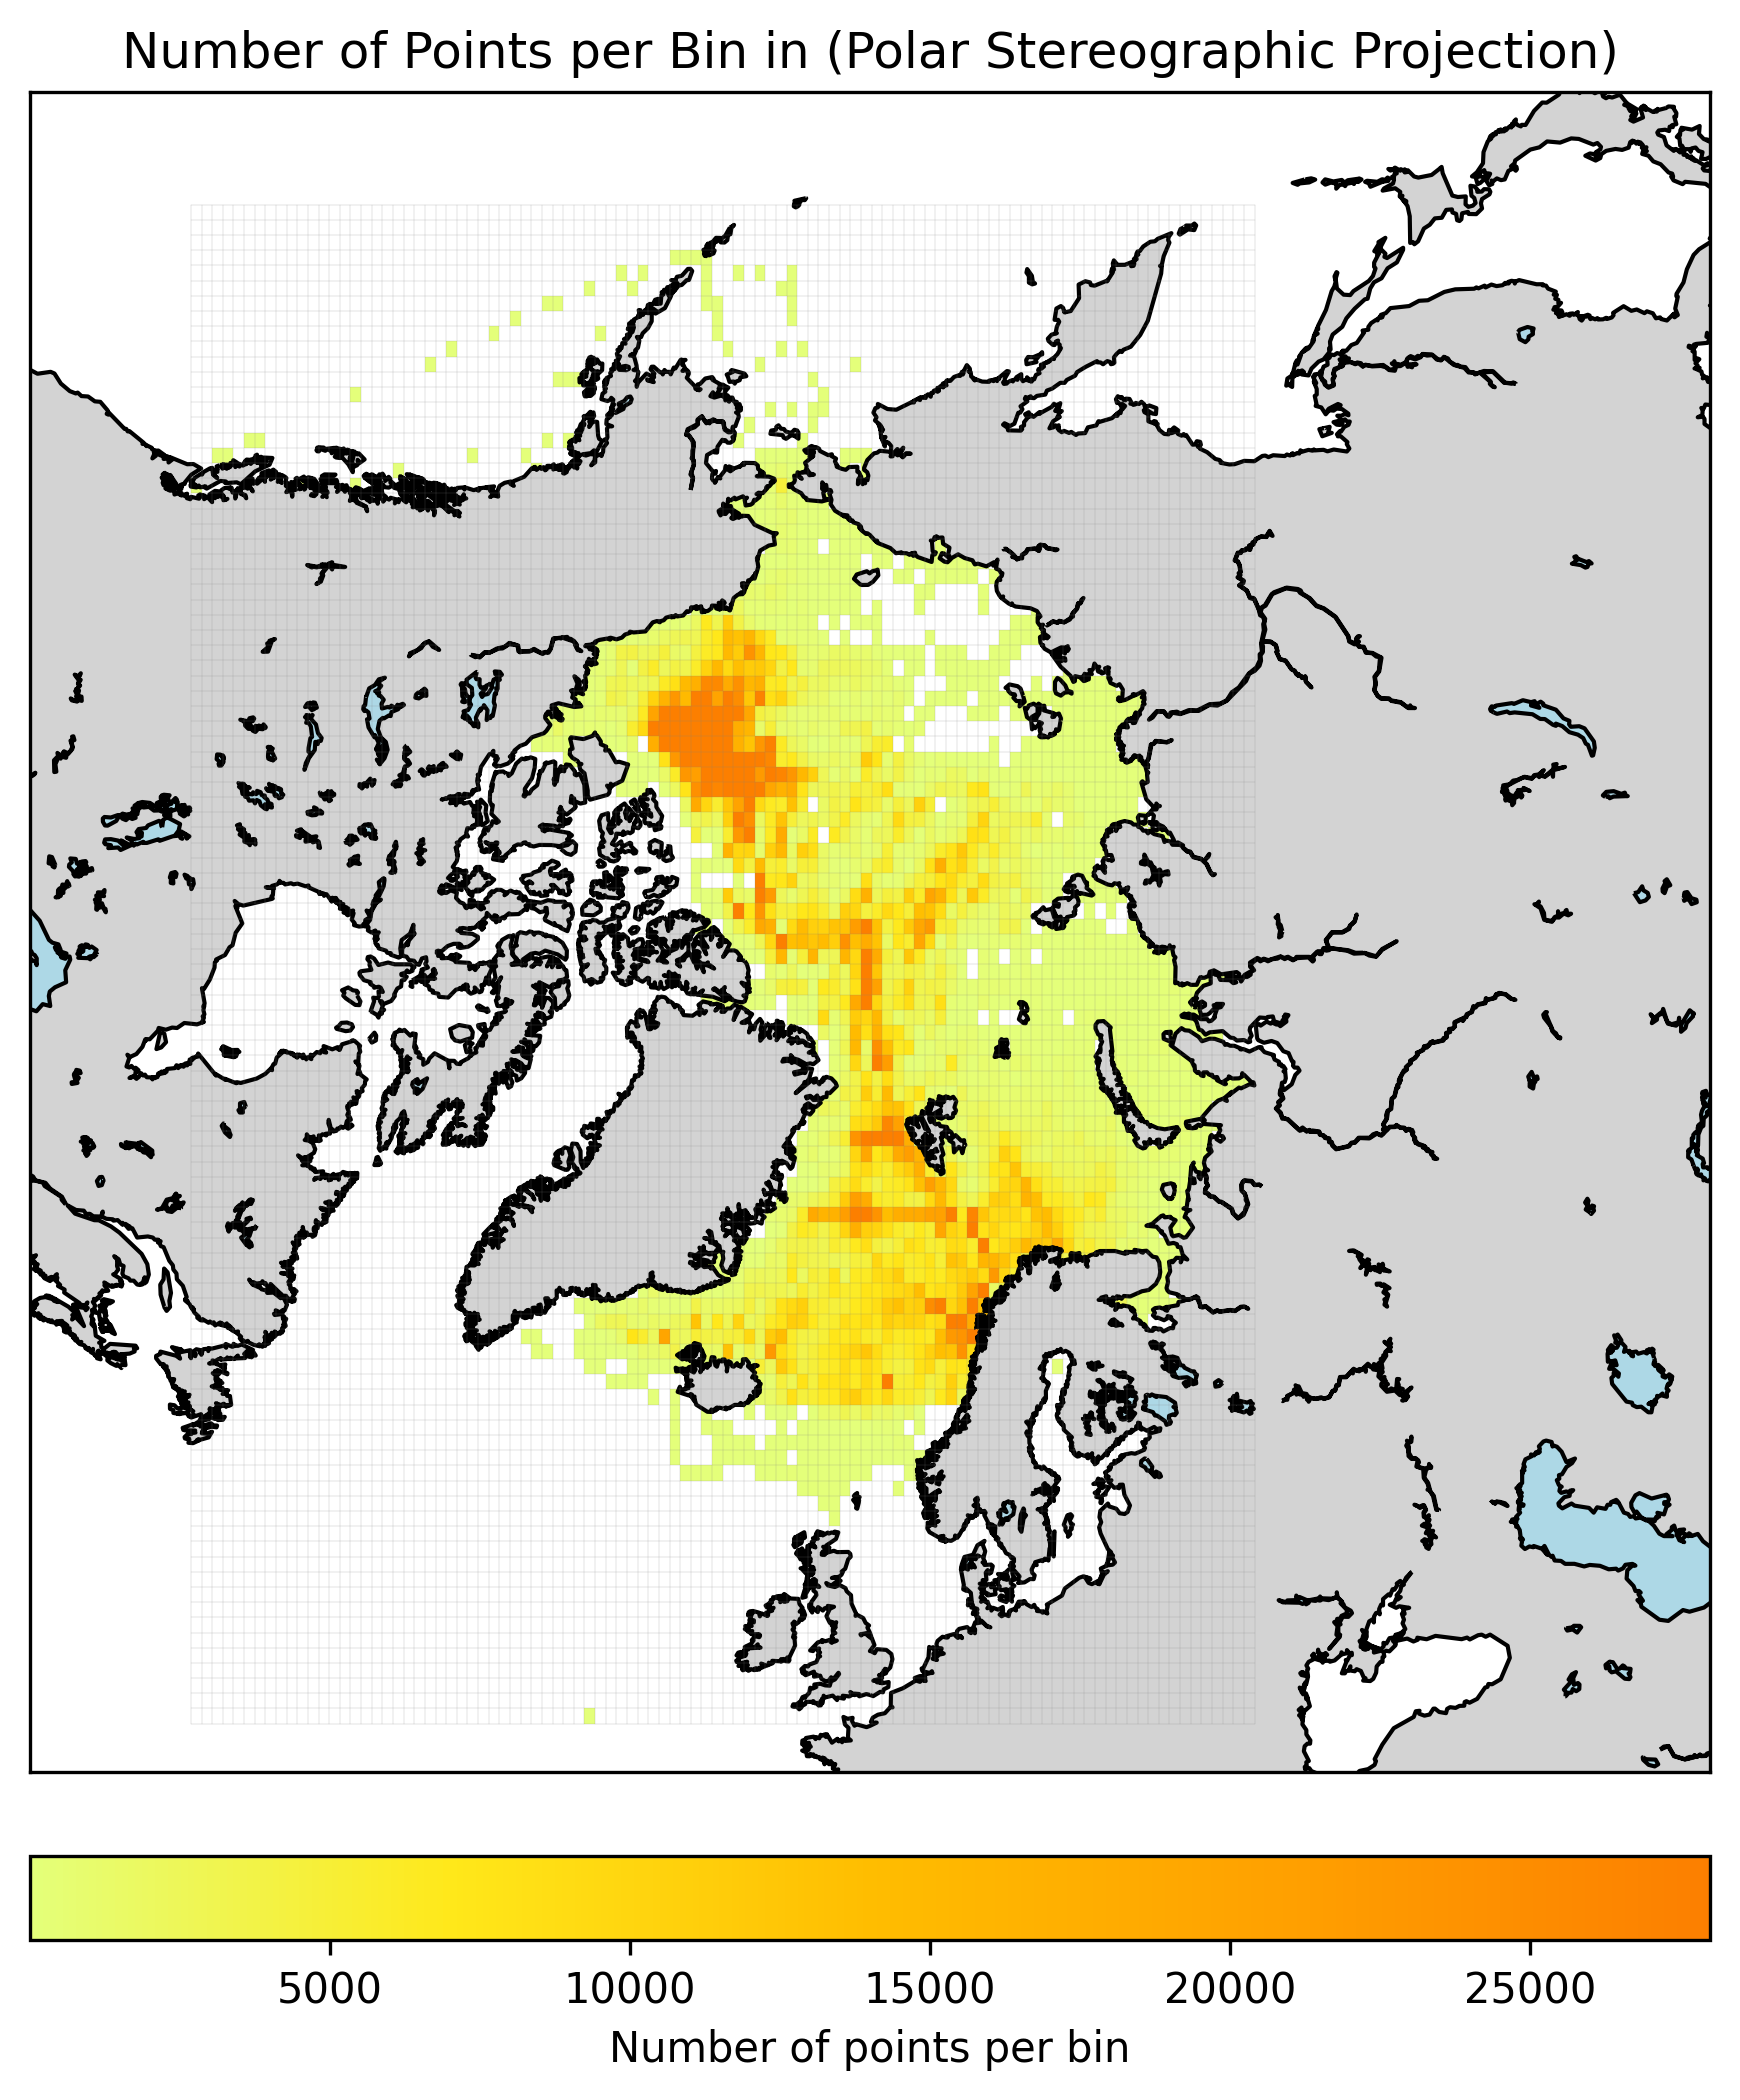

In [46]:
plot_heatmap_npts_xy(df_sampled, n_x_bins=100, n_y_bins=100, projection='npstere', projection_name='Polar Stereographic')

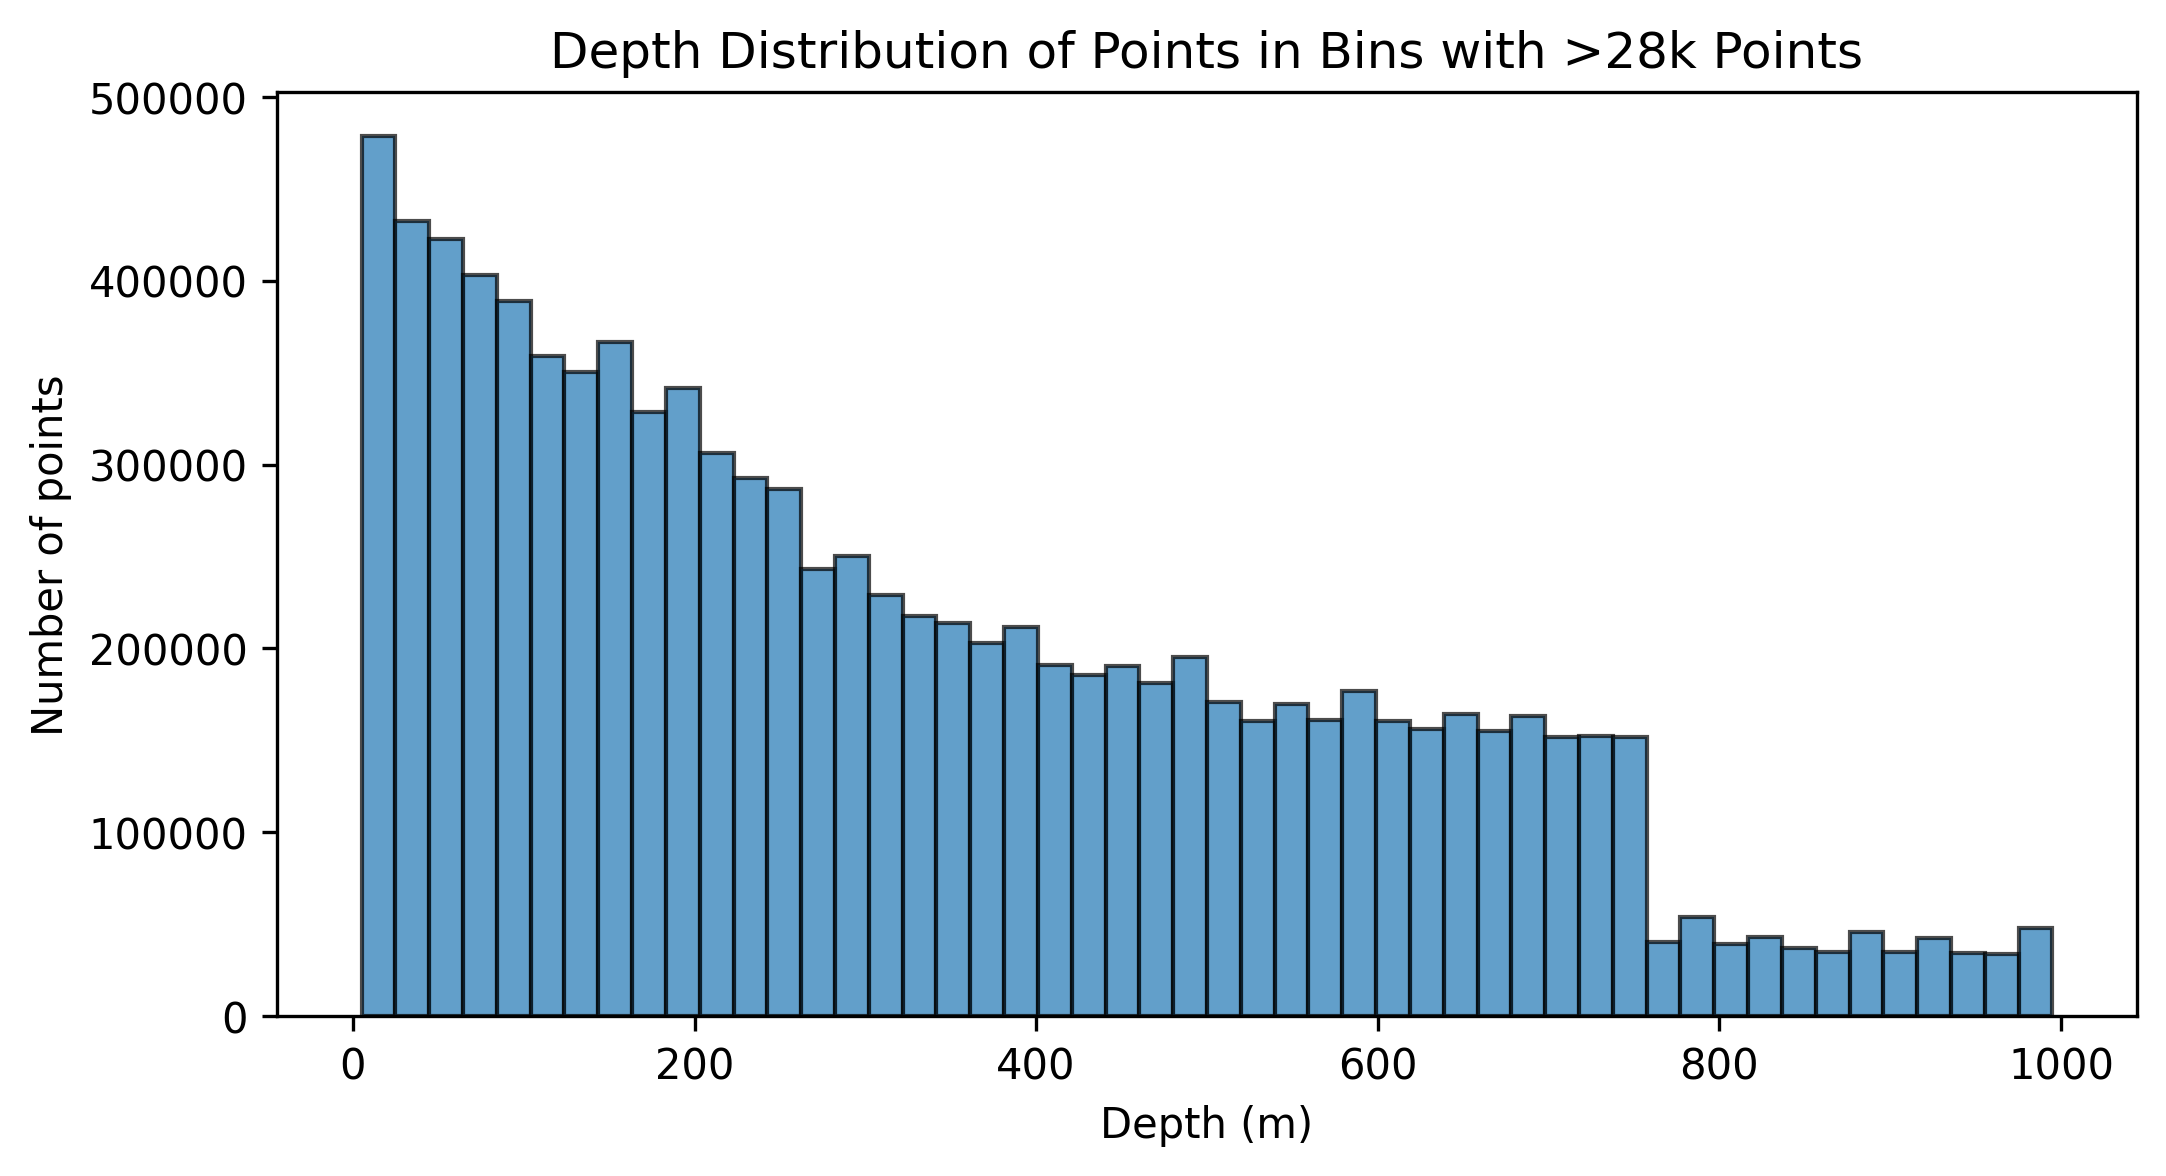

In [49]:
# depth histogram of sampled points
plt.figure(figsize=(8, 4), dpi=300)
plt.hist(df_sampled['Depth_[m]'], bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Depth (m)')
plt.ylabel('Number of points')
plt.title('Depth Distribution of Points in Bins with >28k Points')
plt.show()

In [48]:
profileNo_vs_xy_bins(df_sampled, n_x_bins=100, n_y_bins=100, show_threshold=True, threshold_quantile=0.99, projection='npstere')